# TP 1 - Problema 3: Regresión (Profit por transacción, Superstore)

Objetivo: predecir el valor numérico de la rentabilidad (`Profit`) de una
transacción comercial a partir de las características del pedido, con un
MLP.

Dataset: `Sample - Superstore.csv`, 9994 transacciones y 21 columnas. El objetivo `Profit` es negativo (pérdida) o positivo (ganancia).

Este notebook cubre las 7 consignas: carga, EDA, preprocesamiento, diseño
de la red, entrenamiento, evaluación en dólares, análisis de residuos y
comparación con otros modelos.

### Configuración

Se importan las librerías y se fija la semilla aleatoria (42) en Python,
NumPy y PyTorch. Con la semilla fija, la división de los datos y los
resultados se repiten en cada corrida.

**Cómo ejecutarlo en Colab.** Se sube la carpeta `datasets` de `tp1` a Google
Drive, dentro de `MyDrive/AA2_TP1/`. Se elige un entorno con GPU (Entorno de
ejecución, Cambiar tipo de entorno, GPU) y se ejecutan todas las celdas. La celda
de configuración monta Drive y usa `MyDrive/AA2_TP1` como carpeta de trabajo. Las
figuras quedan en esa carpeta. Fuera de Colab, el notebook corre en CPU con las
rutas locales.

In [1]:
import os
# Solo tiene efecto en GPU: cuBLAS determinista (se define antes de usar CUDA)
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import QuantileRegressor, Ridge
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo y opciones deterministas para GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

# En Colab, los datos y las figuras van a la carpeta AA2_TP1 de Drive, con la misma estructura que tp1/
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/AA2_TP1')
print(f"Dispositivo: {DEVICE}, Colab: {IN_COLAB}, carpeta de trabajo: {os.getcwd()}")

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette("muted")


Mounted at /content/drive
Dispositivo: cuda, Colab: True, carpeta de trabajo: /content/drive/MyDrive/AA2_TP1


Las librerías quedaron cargadas y la semilla fija en 42 para Python,
NumPy y PyTorch. Esta celda no produce salida.

## 1. Carga y verificación del dataset

Se lee el CSV con `pandas` y se verifican dimensiones, tipos, valores
faltantes y filas duplicadas antes de seguir.

Decisión sobre la codificación del archivo: el CSV no está en UTF-8.
Se muestra el error que produce UTF-8 y se lee el archivo con `latin-1`. Un
`assert` verifica que la lectura dejó 9994 filas y 21 columnas, como dice el
enunciado.

In [2]:
DATA_PATH = "datasets/PROBLEMA 3/Sample - Superstore.csv"

# UTF-8 falla con este archivo: se muestra el error y se usa latin-1
try:
    pd.read_csv(DATA_PATH, encoding="utf-8")
    print("UTF-8: lectura correcta")
except UnicodeDecodeError as error:
    print(f"UTF-8 falla: {error.reason} (byte {error.start})")

df = pd.read_csv(DATA_PATH, encoding="latin-1")

assert df.shape == (9994, 21), df.shape
assert df.isna().sum().sum() == 0
assert not df.duplicated().any()
assert df['Country'].nunique() == 1

print(f"\nFilas: {df.shape[0]}, columnas: {df.shape[1]}")
print(f"Valores faltantes: {int(df.isna().sum().sum())}, "
      f"filas duplicadas: {int(df.duplicated().sum())}")
print(f"Niveles de Country: {df['Country'].nunique()} ({df['Country'].iloc[0]})")
print()
df.info()
df.head(3)


UTF-8 falla: invalid start byte (byte 9)

Filas: 9994, columnas: 21
Valores faltantes: 0, filas duplicadas: 0
Niveles de Country: 1 (United States)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   obje

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


El archivo no se abre como UTF-8: falla con `invalid start byte` en el
byte 9. Con `latin-1` se lee bien. Quedan 9994 filas y 21 columnas, sin
valores faltantes ni filas duplicadas, como dice el enunciado.

Hay 15 columnas de texto, 3 enteras (`Row ID`, `Postal Code` y `Quantity`) y 3
decimales (`Sales`, `Discount` y `Profit`). `Country` tiene un solo valor
(United States), así que no aporta información. Las fechas están como texto
y hay que convertirlas (sección 3.2).

## 2. Análisis exploratorio de datos (EDA)

### 2.1 Distribución de `Profit`

Esta sección mira la forma de la variable objetivo: su centro, su dispersión, la
proporción de valores negativos y las colas. Se usan cuatro vistas del mismo
dato, porque una sola escala no muestra todo:

- **Histograma completo** con eje vertical logarítmico.
- **Histograma ampliado** cerca de cero, donde está la mayoría de los datos.
- **Diagrama de caja**, que muestra los valores extremos.
- **Escala logarítmica con signo**, `sign(y) * log10(1 + |y|)`. Permite ver
  juntas la cola negativa y la positiva.

media                  28.66
mediana                 8.67
desvio                234.26
minimo              -6599.98
maximo               8399.98
q25                     1.73
q75                    29.36
asimetria               7.56
curtosis (exceso)     397.19

Valores negativos: 1871 (18.7%), media de los negativos: -83.45
Valores exactamente 0: 65


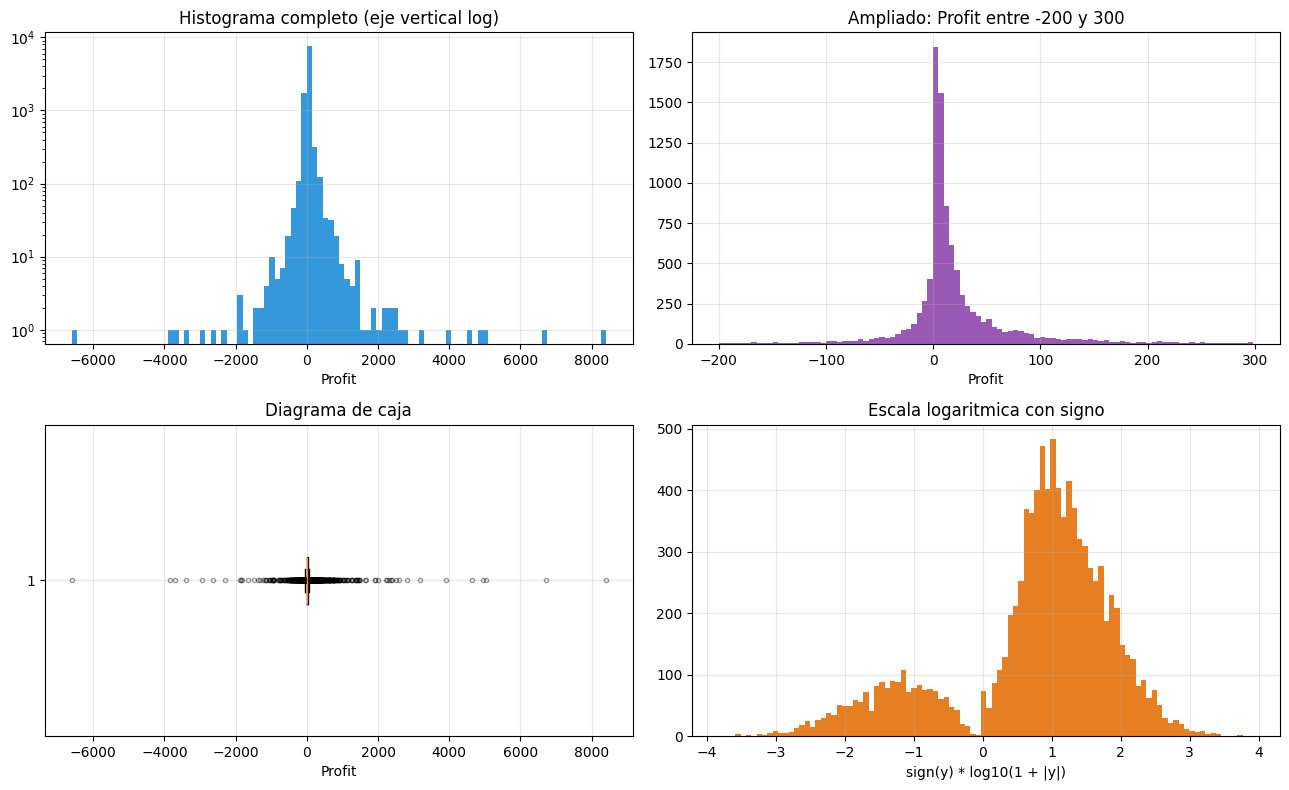

In [3]:
profit = df['Profit']
negative_profit = profit[profit < 0]

summary = pd.Series({
    'media': profit.mean(), 'mediana': profit.median(), 'desvio': profit.std(),
    'minimo': profit.min(), 'maximo': profit.max(),
    'q25': profit.quantile(0.25), 'q75': profit.quantile(0.75),
    'asimetria': profit.skew(), 'curtosis (exceso)': profit.kurt(),
})
print(summary.round(2).to_string())
print(f"\nValores negativos: {len(negative_profit)} ({(profit < 0).mean() * 100:.1f}%), "
      f"media de los negativos: {negative_profit.mean():.2f}")
print(f"Valores exactamente 0: {int((profit == 0).sum())}")

signed_log = np.sign(profit) * np.log10(1 + profit.abs())

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].hist(profit, bins=100, color='#3498db')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Histograma completo (eje vertical log)')
axes[0, 1].hist(profit[profit.between(-200, 300)], bins=100, color='#9b59b6')
axes[0, 1].set_title('Ampliado: Profit entre -200 y 300')
axes[1, 0].boxplot(profit, orientation='horizontal', flierprops={'markersize': 3, 'alpha': 0.4})
axes[1, 0].set_title('Diagrama de caja')
axes[1, 1].hist(signed_log, bins=100, color='#e67e22')
axes[1, 1].set_title('Escala logaritmica con signo')
for ax in axes.flat:
    ax.set_xlabel('Profit' if ax is not axes[1, 1] else 'sign(y) * log10(1 + |y|)')
plt.tight_layout()
plt.savefig('p3_01_distribucion_profit.png', dpi=110, bbox_inches='tight')
plt.show()


**Centro y dispersión.** La mediana de `Profit` es 8.67 y la media es 28.66,
3.3 veces mayor. El desvío es 234.26, unas 8.5 veces el rango intercuartil
(27.64). La mitad central de las transacciones tiene un `Profit` entre 1.73 y
29.36, pero el rango total va de -6599.98 a 8399.98.

**Colas.** La asimetría es 7.56 y la curtosis en exceso es 397.19 (una
distribución normal tiene 0). Son colas extremadamente pesadas, tanto en el
lado negativo como en el positivo.

**Pérdidas.** El 18.7% de las filas (1871) tiene `Profit` negativo, con una
media de -83.45 en esas filas. Hay 65 filas con `Profit` exactamente 0.

**Qué muestra cada vista.** El histograma completo solo deja ver las colas,
con pocas filas por encima de 2000 o por debajo de -2000. El ampliado
muestra un pico muy estrecho cerca de cero, con un hombro largo hacia la
derecha. El diagrama de caja casi no informa: la caja es una línea, y los
puntos extremos forman una banda. La escala logarítmica con signo es la vista más clara. Separa un grupo
positivo grande, con su centro en unos 10 dólares, de un grupo negativo más
chico y más disperso.

**Consecuencia.** Con una función de costo cuadrática (MSE), las pocas filas extremas dominan el entrenamiento. La media y la mediana de `Profit` son muy distintas. Un modelo entrenado
para predecir la media y otro entrenado para predecir la mediana darán
resultados diferentes. Esto se mide en la sección de funciones de costo.

### 2.2 Valores extremos

El enunciado pide identificar la presencia de *outliers*. Se prueba la regla clásica del rango intercuartil: valores fuera de
`Q1 - 1.5 IQR` y `Q3 + 1.5 IQR`. Se mira si sirve para esta variable. Después se mide cuánto del `Profit` total está en las filas más extremas.
También se miran los casos extremos concretos, para decidir si son errores
o eventos reales.

In [4]:
q1, q3 = profit.quantile([0.25, 0.75])
iqr = q3 - q1
low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
below, above = (profit < low_fence), (profit > high_fence)
print(f"IQR = {iqr:.2f}, cercas: [{low_fence:.1f}, {high_fence:.1f}]")
print(f"Filas fuera de las cercas: {(below | above).mean() * 100:.1f}% "
      f"(bajo {below.mean() * 100:.1f}%, sobre {above.mean() * 100:.1f}%)")

abs_profit = profit.abs().sort_values(ascending=False)
for share in (0.01, 0.05):
    n_top = int(len(profit) * share)
    print(f"El {share * 100:.0f}% de filas con mayor |Profit| ({n_top}) "
          f"concentra {abs_profit.iloc[:n_top].sum() / abs_profit.sum() * 100:.1f}% "
          f"del |Profit| total")
inner = profit[profit.abs() < profit.abs().quantile(0.99)]
print(f"Desvio con todas las filas: {profit.std():.1f}, "
      f"sin el 1% mas extremo: {inner.std():.1f}")

columns_to_show = ['Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']
print("\nLos 5 mayores Profit:")
print(df.nlargest(5, 'Profit')[columns_to_show].round(2).to_string())
print("\nLos 5 menores Profit:")
print(df.nsmallest(5, 'Profit')[columns_to_show].round(2).to_string())


IQR = 27.64, cercas: [-39.7, 70.8]
Filas fuera de las cercas: 18.8% (bajo 6.0%, sobre 12.8%)
El 1% de filas con mayor |Profit| (99) concentra 28.1% del |Profit| total
El 5% de filas con mayor |Profit| (499) concentra 53.1% del |Profit| total
Desvio con todas las filas: 234.3, sin el 1% mas extremo: 90.5

Los 5 mayores Profit:
     Sub-Category     Sales  Quantity  Discount   Profit
6826      Copiers  17499.95         5       0.0  8399.98
8153      Copiers  13999.96         4       0.0  6719.98
4190      Copiers  10499.97         3       0.0  5039.99
9039      Binders   9892.74        13       0.0  4946.37
4098      Binders   9449.95         5       0.0  4630.48

Los 5 menores Profit:
     Sub-Category    Sales  Quantity  Discount   Profit
7772     Machines  4499.98         5       0.7 -6599.98
683      Machines  7999.98         4       0.5 -3839.99
9774      Binders  2177.58         8       0.8 -3701.89
3011     Machines  2549.98         5       0.7 -3399.98
4991      Binders  1889.99 

**La regla del IQR no sirve aquí.** Las cercas son [-39.7, 70.8], y el 18.8%
de las filas queda afuera (6.0% por debajo y 12.8% por encima). Marca casi
una fila de cada cinco, porque la distribución es muy estrecha en el centro
y de colas pesadas. Con esa regla, el "outlier" es la norma.

**Concentración.** El 1% de las filas con mayor `|Profit|` (99 filas)
concentra el 28.1% del `|Profit|` total. El 5% (499 filas) concentra el
53.1%. Sin el 1% más extremo, el desvío baja de 234.3 a 90.5.

**Los extremos son eventos reales, no errores.**

- Los mayores `Profit` son copiadoras (`Copiers`) y encuadernadoras
  (`Binders`) sin descuento, con ventas de 9449 a 17500. Su margen
  (`Profit / Sales`) es de 0.48 a 0.50.
- Los menores `Profit` son `Machines` y `Binders` con descuentos de 0.5 a
  0.8. En 4 de los 5 casos más chicos, la pérdida supera el monto vendido.

Cada extremo se explica por el descuento, la subcategoría y el monto de la
venta.

**Decisión.** Se mantienen todas las filas. Si se borran los extremos, se esconden los casos más costosos para el negocio. En su lugar, se tratan con una
función de costo robusta y un escalado robusto. La consecuencia es que las
métricas de test dependerán de pocas filas, y esto se tendrá en cuenta al
evaluar.

### 2.3 Relación entre las variables predictoras y `Profit`

Se grafica `Profit` contra cada predictor numérico, y contra las
categorías más relevantes. Como `Profit` y `Sales` tienen colas muy largas,
se usan escalas logarítmicas (`symlog` para `Profit`, que tiene valores
negativos). Se agrega el **margen** `Profit / Sales`, que solo se usa en el
EDA: usa el objetivo, y por eso no es una variable predictora válida.

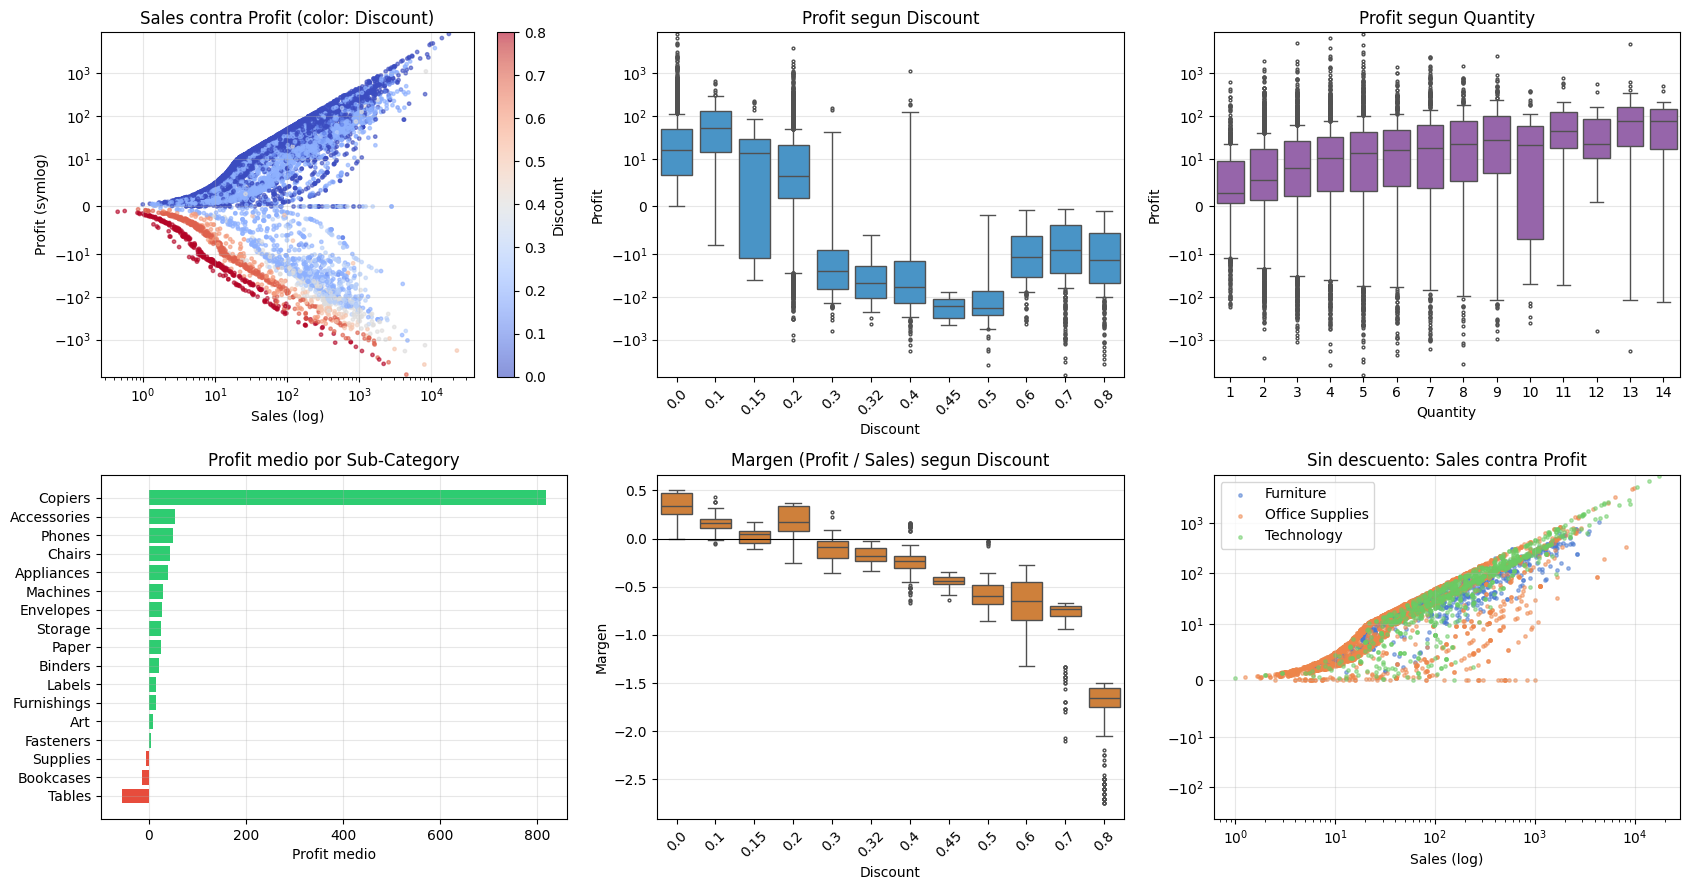

          filas  profit_medio  perdidas_pct  margen_mediano
Discount                                                   
0.00       4798         66.90          0.00            0.34
0.10         94         96.06          4.26            0.17
0.15         52         27.29         32.69            0.05
0.20       3657         24.70         13.73            0.18
0.30        227        -45.68         91.63           -0.09
0.32         27        -88.56        100.00           -0.18
0.40        206       -111.93         87.38           -0.23
0.45         11       -226.65        100.00           -0.44
0.50         66       -310.70        100.00           -0.60
0.60        138        -43.08        100.00           -0.65
0.70        418        -95.87        100.00           -0.73
0.80        300       -101.80        100.00           -1.65


In [5]:
df_eda = df.copy()
df_eda['Margen'] = df_eda['Profit'] / df_eda['Sales']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

scatter = axes[0, 0].scatter(df_eda['Sales'], df_eda['Profit'], c=df_eda['Discount'],
                             cmap='coolwarm', s=6, alpha=0.6)
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('symlog', linthresh=10)
axes[0, 0].set_xlabel('Sales (log)')
axes[0, 0].set_ylabel('Profit (symlog)')
axes[0, 0].set_title('Sales contra Profit (color: Discount)')
plt.colorbar(scatter, ax=axes[0, 0], label='Discount')

sns.boxplot(data=df_eda, x='Discount', y='Profit', ax=axes[0, 1], color='#3498db',
            fliersize=2)
axes[0, 1].set_yscale('symlog', linthresh=10)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_title('Profit segun Discount')

sns.boxplot(data=df_eda, x='Quantity', y='Profit', ax=axes[0, 2], color='#9b59b6',
            fliersize=2)
axes[0, 2].set_yscale('symlog', linthresh=10)
axes[0, 2].set_title('Profit segun Quantity')

by_sub = df_eda.groupby('Sub-Category')['Profit'].mean().sort_values()
axes[1, 0].barh(by_sub.index, by_sub.values,
                color=['#e74c3c' if v < 0 else '#2ecc71' for v in by_sub.values])
axes[1, 0].set_xlabel('Profit medio')
axes[1, 0].set_title('Profit medio por Sub-Category')

sns.boxplot(data=df_eda, x='Discount', y='Margen', ax=axes[1, 1], color='#e67e22',
            fliersize=2)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_title('Margen (Profit / Sales) segun Discount')

no_discount = df_eda[df_eda['Discount'] == 0]
for category, group in no_discount.groupby('Category'):
    axes[1, 2].scatter(group['Sales'], group['Profit'], s=6, alpha=0.5, label=category)
axes[1, 2].set_xscale('log')
axes[1, 2].set_yscale('symlog', linthresh=10)
axes[1, 2].set_xlabel('Sales (log)')
axes[1, 2].set_title('Sin descuento: Sales contra Profit')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('p3_02_relaciones_predictores.png', dpi=110, bbox_inches='tight')
plt.show()

discount_table = df_eda.groupby('Discount').agg(
    filas=('Profit', 'size'), profit_medio=('Profit', 'mean'),
    perdidas_pct=('Profit', lambda s: (s < 0).mean() * 100),
    margen_mediano=('Margen', 'median')).round(2)
print(discount_table.to_string())


**`Sales` y `Discount` definen la estructura.** En el gráfico de `Sales`
contra `Profit` (escalas logarítmicas), las filas forman dos abanicos. Con
descuento bajo (azul), el `Profit` sube con `Sales`. Con descuento alto
(rojo), baja. Es decir, `Profit` crece casi en proporción a `Sales`, y el
descuento fija el signo y la pendiente. Sin descuento (panel inferior
derecho), las filas forman una banda angosta, con margen de hasta 0.50.

**`Discount`.** La mediana de `Profit` es positiva con descuentos de 0 a 0.2
y negativa desde 0.3. La tabla lo confirma: con descuento 0, ninguna fila
pierde (0.00%). Con 0.20 pierde el 13.73%, con 0.30 el 91.63%, y con 0.32 o
más pierde el 100% (salvo 0.40, con 87.38%). El margen mediano baja de 0.34
(sin descuento) a -0.09 (descuento 0.30) y a -1.65 (descuento 0.80). La
relación no es perfectamente monótona: el grupo 0.15 (52 filas) tiene un
margen mediano de 0.05, menor que el de 0.20 (0.18).

**`Quantity`.** Tiene poca relación: la mediana de `Profit` sube despacio
con la cantidad, y las cajas se superponen mucho.

**Subcategoría.** `Copiers` tiene el mayor `Profit` medio, cerca de 800, muy
por encima del resto. `Tables`, `Bookcases` y `Supplies` tienen `Profit`
medio negativo.

**Consecuencia para el modelo.** `Sales`, `Discount` y la subcategoría son
los predictores principales. `Profit` es igual al margen por `Sales`, por definición del margen. El
margen depende del descuento y de la subcategoría. El MLP debe aprender esa
relación multiplicativa sobre una variable `Sales` con colas muy largas.

### 2.4 Matrices de correlación

Se calculan dos correlaciones entre las variables numéricas y `Profit`:

- **Pearson**: mide relación lineal, y es sensible a los valores extremos.
- **Spearman**: mide relación monótona sobre los rangos, y no depende de
  los valores extremos.

Si las dos difieren mucho, la relación no es lineal o los extremos dominan.
Se incluye el margen, que solo se usa aquí.

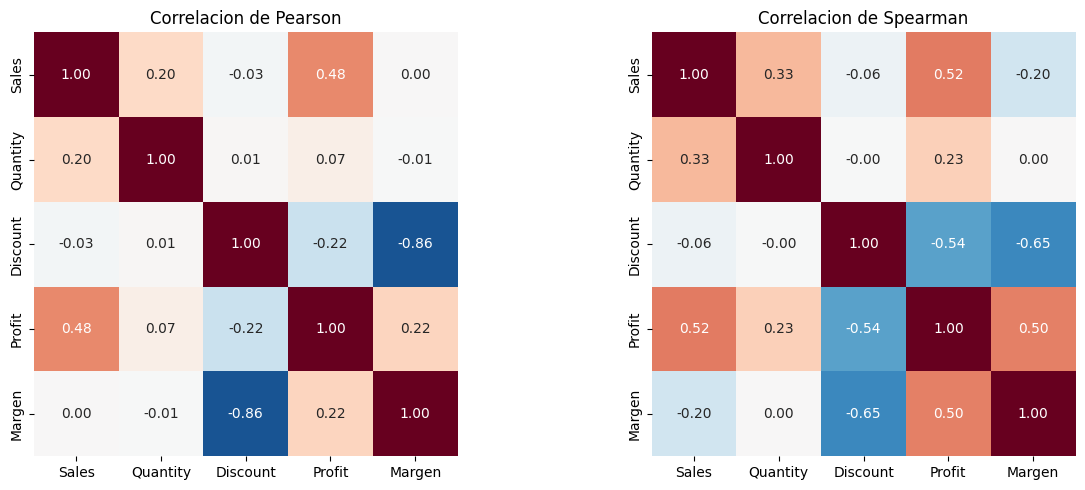

Correlacion con Profit:
          Pearson  Spearman
Sales       0.479     0.518
Quantity    0.066     0.234
Discount   -0.219    -0.543
Margen      0.224     0.500


In [6]:
numeric_columns = ['Sales', 'Quantity', 'Discount', 'Profit', 'Margen']
pearson = df_eda[numeric_columns].corr(method='pearson')
spearman = df_eda[numeric_columns].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, matrix, title in [(axes[0], pearson, 'Pearson'), (axes[1], spearman, 'Spearman')]:
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1,
                vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(f'Correlacion de {title}')
    ax.grid(False)
plt.tight_layout()
plt.savefig('p3_03_correlaciones.png', dpi=110, bbox_inches='tight')
plt.show()

comparison = pd.DataFrame({'Pearson': pearson['Profit'], 'Spearman': spearman['Profit']})
print("Correlacion con Profit:")
print(comparison.drop(index=['Profit']).round(3).to_string())


Correlación con `Profit`:

| Variable | Pearson | Spearman |
|---|---|---|
| `Sales` | 0.479 | 0.518 |
| `Quantity` | 0.066 | 0.234 |
| `Discount` | -0.219 | -0.543 |
| Margen (solo EDA) | 0.224 | 0.500 |

`Sales` tiene una correlación similar con los dos métodos. `Discount` y
`Quantity` no: la de Spearman es mucho mayor. Para `Discount`, -0.543 frente
a -0.219. Eso indica una relación monótona pero no lineal, y con valores
extremos que reducen la correlación de Pearson. La tabla de la sección 2.3 muestra la forma. El `Profit` cambia de signo
alrededor de un descuento de 0.3, como un escalón y no como una recta.

La correlación lineal subestima la importancia de `Discount`. Estas
matrices solo incluyen variables numéricas. No miden el efecto de las
categorías, como la subcategoría.

### 2.5 Variables de alta cardinalidad

El enunciado pide identificar las variables con muchos niveles y decidir
una estrategia. Se cuentan los niveles de cada columna de texto y de
`Postal Code`, y cuántas filas tiene cada nivel. Un nivel con pocas filas da poca información para aprender su efecto. Una
columna con miles de niveles crea miles de columnas si se codifica con
one-hot.

In [7]:
categorical_columns = df.select_dtypes(exclude='number').columns.tolist() + ['Postal Code']
categorical_columns = [c for c in categorical_columns if c not in ('Order Date', 'Ship Date')]

cardinality_rows = []
for column in categorical_columns:
    rows_per_level = df[column].value_counts()
    cardinality_rows.append({
        'columna': column, 'niveles': len(rows_per_level),
        'filas_por_nivel_min': int(rows_per_level.min()),
        'filas_por_nivel_mediana': float(rows_per_level.median()),
        'filas_por_nivel_max': int(rows_per_level.max()),
    })
cardinality = pd.DataFrame(cardinality_rows).sort_values('niveles', ascending=False)
print(cardinality.to_string(index=False))

# Nombres e IDs que se repiten entre si
ids_with_many_names = int((df.groupby('Product ID')['Product Name'].nunique() > 1).sum())
names_with_many_ids = int((df.groupby('Product Name')['Product ID'].nunique() > 1).sum())
print(f"\nProduct ID con mas de un nombre: {ids_with_many_names}. "
      f"Product Name con mas de un ID: {names_with_many_ids}.")
orders = df.groupby('Order ID').size()
print(f"Filas por Order ID: media {orders.mean():.2f}, maximo {orders.max()}. "
      f"Pedidos con mas de una fila: {(orders > 1).mean() * 100:.1f}%.")


      columna  niveles  filas_por_nivel_min  filas_por_nivel_mediana  filas_por_nivel_max
     Order ID     5009                    1                      1.0                   14
   Product ID     1862                    1                      5.0                   19
 Product Name     1850                    1                      5.0                   48
  Customer ID      793                    1                     12.0                   37
Customer Name      793                    1                     12.0                   37
  Postal Code      631                    1                      6.0                  263
         City      531                    1                      5.0                  915
        State       49                    1                     82.0                 2001
 Sub-Category       17                   68                    466.0                 1523
    Ship Mode        4                  543                   1741.5                 5968
       Reg

**Tabla de cardinalidad.**

- `Order ID` (5009 niveles), `Product ID` (1862), `Product Name` (1850),
  `Customer ID` y `Customer Name` (793): los niveles tienen 1 a 12 filas en
  mediana. Son identificadores. Un modelo no aprende un efecto general de un nivel con 1 a 5 filas.
- `Postal Code` (631) y `City` (531): mediana de 5 a 6 filas por nivel.
- `State`: 49 niveles, con una mediana de 82 filas y un mínimo de 1.
- `Sub-Category` (17, mínimo de 68 filas por nivel), `Ship Mode` (4),
  `Region` (4), `Segment` (3) y `Category` (3): cardinalidad baja, con muchas
  filas por nivel.
- `Country` tiene 1 nivel.

**Problemas de calidad.** 32 `Product ID` tienen más de un nombre y 16
`Product Name` tienen más de un ID. Es otra razón para no usar esas columnas.

**Estrategia.**

- Se eliminan los identificadores (`Order ID` se conserva aparte, para
  dividir los datos) y `Country`.
- Se eliminan `City` y `Postal Code`: cientos de niveles con pocas filas.
  `State` y `Region` conservan la información geográfica.
- Se codifican con one-hot las variables de cardinalidad baja. `State` (49
  niveles) es el caso límite: se mantiene y más adelante se mide si aporta.

El 49.3% de los pedidos tiene más de una fila (2.00 en promedio, máximo 14).
Esto motiva dividir los datos por pedido (sección 3.3).

## 3. Preprocesamiento

### 3.1 Eliminar columnas no predictivas

Se eliminan tres grupos de columnas:

- **Identificadores**: `Row ID`, `Order ID`, `Customer ID`, `Customer Name`,
  `Product ID`, `Product Name`. No describen el pedido: identifican una fila
  o una entidad. Con miles de niveles, un MLP los memoriza.
- **Constante**: `Country`. Tiene un solo valor y no explica nada.
- **Ubicación de alta cardinalidad**: `City` y `Postal Code`. Tienen cientos
  de niveles con pocas filas cada uno. `State` y `Region` conservan la
  información geográfica.

`Order ID` no entra al modelo, pero se guarda aparte: se usa para
dividir los datos por pedido (sección 3.3).

In [8]:
identifier_columns = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name',
                      'Product ID', 'Product Name']
constant_columns = ['Country']
high_cardinality_columns = ['City', 'Postal Code']
dropped_columns = identifier_columns + constant_columns + high_cardinality_columns

order_groups = df['Order ID'].copy()      # solo para dividir por pedido
df_model = df.drop(columns=dropped_columns)

print(f"Columnas eliminadas ({len(dropped_columns)}): {dropped_columns}")
print(f"Columnas restantes ({df_model.shape[1]}): {df_model.columns.tolist()}")
assert 'Profit' in df_model.columns and 'Order ID' not in df_model.columns


Columnas eliminadas (9): ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name', 'Country', 'City', 'Postal Code']
Columnas restantes (12): ['Order Date', 'Ship Date', 'Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


Se eliminaron 9 columnas: 6 identificadores, `Country`, `City` y `Postal
Code`. Quedan 12 columnas: las dos fechas, `Ship Mode`, `Segment`, `State`,
`Region`, `Category`, `Sub-Category`, `Sales`, `Quantity`, `Discount` y el
objetivo `Profit`. `Order ID` se guardó aparte, solo para dividir por pedido.

### 3.2 Características de las fechas

`Order Date` y `Ship Date` son texto con formato `mes/dia/año`. Se
convierten a fecha y se extraen:

- De `Order Date`: año, mes, día del mes, trimestre y día de la semana.
- De las dos fechas: la **demora de envío** en días (`Ship Date` menos
  `Order Date`). El enunciado la menciona como útil.

Después se eliminan las dos columnas de fecha originales. Un `assert`
verifica que todas las fechas se convirtieron.

In [9]:
order_date = pd.to_datetime(df_model['Order Date'], format='%m/%d/%Y')
ship_date = pd.to_datetime(df_model['Ship Date'], format='%m/%d/%Y')
assert order_date.notna().all() and ship_date.notna().all()

df_model['order_year'] = order_date.dt.year
df_model['order_month'] = order_date.dt.month
df_model['order_day'] = order_date.dt.day
df_model['order_quarter'] = order_date.dt.quarter
df_model['order_weekday'] = order_date.dt.dayofweek
df_model['ship_delay_days'] = (ship_date - order_date).dt.days
df_model = df_model.drop(columns=['Order Date', 'Ship Date'])

print(f"Rango de Order Date: {order_date.min().date()} a {order_date.max().date()}")
print(df_model[['order_year', 'order_month', 'order_day', 'order_quarter',
                'order_weekday', 'ship_delay_days']].agg(['min', 'max']).to_string())
print("\nDemora de envio (dias): frecuencia")
print(df_model['ship_delay_days'].value_counts().sort_index().to_string())
print("\nDemora media de envio segun Ship Mode:")
print(df_model.groupby('Ship Mode')['ship_delay_days'].mean().round(2).to_string())


Rango de Order Date: 2014-01-03 a 2017-12-30
     order_year  order_month  order_day  order_quarter  order_weekday  ship_delay_days
min        2014            1          1              1              0                0
max        2017           12         31              4              6                7

Demora de envio (dias): frecuencia
ship_delay_days
0     519
1     369
2    1334
3    1005
4    2774
5    2169
6    1203
7     621

Demora media de envio segun Ship Mode:
Ship Mode
First Class       2.18
Same Day          0.04
Second Class      3.24
Standard Class    5.01


Las órdenes van del 2014-01-03 al 2017-12-30, cuatro años. Los rangos de las características son los esperables. El año va de 2014 a 2017 y el mes de 1 a 12. El día va de 1 a 31 y el
trimestre de 1 a 4. El día de
la semana va de 0 a 6, y la demora de envío de 0 a 7 días. Todas las fechas
se convirtieron sin errores.

La demora de envío está muy ligada al modo de envío. `Same Day` tiene 0.04
días de media, `First Class` 2.18, `Second Class` 3.24 y `Standard Class`
5.01. Las dos variables están relacionadas. Se conservan las dos, y no
se mide si la demora aporta algo más que el modo de envío.

### 3.3 División en train, validación y test, por pedido

Se dividen los datos **por `Order ID`**, no por fila. Razón: los 9994 registros
vienen de 5009 pedidos, y las filas de un mismo pedido comparten cliente,
fechas, modo de envío y estado. Si una fila está en train y otra del mismo pedido está en test, el modelo reconoce el pedido y usa a su hermana. Eso mide memorización, no predicción para pedidos nuevos.

Decisiones:

- **70% / 15% / 15%**, contando pedidos. `GroupShuffleSplit` mantiene cada
  pedido entero en un solo conjunto.
- La división se hace **antes** de ajustar cualquier transformación, para
  que validación y test no influyan en el preprocesamiento.
- El test se usa una sola vez, al final.

Se mide también la fuga de una división aleatoria por filas. Además se revisa cómo quedan los valores extremos de `Profit` en cada conjunto. Con
pocas filas extremas, una sola fila en el conjunto equivocado cambia mucho
las métricas.

In [10]:
groups = order_groups.values

# Primero se separa el test (15% de los pedidos), despues la validacion
outer_split = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(outer_split.split(df_model, groups=groups))
inner_split = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=SEED)
relative_train, relative_val = next(
    inner_split.split(df_model.iloc[train_val_idx], groups=groups[train_val_idx]))
train_idx, val_idx = train_val_idx[relative_train], train_val_idx[relative_val]

split_indices = {'train': train_idx, 'val': val_idx, 'test': test_idx}

# Ningun pedido aparece en dos conjuntos
orders_by_split = {name: set(groups[idx]) for name, idx in split_indices.items()}
assert not (orders_by_split['train'] & orders_by_split['val'])
assert not (orders_by_split['train'] & orders_by_split['test'])
assert not (orders_by_split['val'] & orders_by_split['test'])
assert sum(len(idx) for idx in split_indices.values()) == len(df_model)

profit_values = df_model['Profit'].values
top_extreme_rows = set(np.argsort(-np.abs(profit_values))[:20])
split_rows = []
for name, idx in split_indices.items():
    split_profit = profit_values[idx]
    split_rows.append({
        'conjunto': name, 'filas': len(idx), 'pedidos': len(orders_by_split[name]),
        'filas_%': len(idx) / len(df_model) * 100,
        'profit_medio': split_profit.mean(), 'profit_mediano': np.median(split_profit),
        'profit_desvio': split_profit.std(), 'profit_min': split_profit.min(),
        'profit_max': split_profit.max(), 'negativos_%': (split_profit < 0).mean() * 100,
        'de_los_20_mas_extremos': len(top_extreme_rows & set(idx)),
    })
print(pd.DataFrame(split_rows).set_index('conjunto').round(2).T.to_string())

# Comparacion: una division aleatoria por filas del 15% para test
random_generator = np.random.RandomState(SEED)
random_order = random_generator.permutation(len(df_model))
random_test = random_order[:int(0.15 * len(df_model))]
random_train = random_order[int(0.30 * len(df_model)):]
leak_random = np.isin(groups[random_test], groups[random_train]).mean() * 100
leak_grouped = np.isin(groups[test_idx], groups[train_idx]).mean() * 100
print("\nFilas de test cuyo pedido tambien esta en train:")
print(f"  division aleatoria por filas: {leak_random:.1f}%")
print(f"  division por pedido:          {leak_grouped:.1f}%")

# Clientes y productos si se repiten entre conjuntos, y es legitimo: los pedidos
# nuevos vienen de clientes y productos conocidos
test_rows = df.iloc[test_idx]
train_rows = df.iloc[train_idx]
customer_overlap = test_rows['Customer ID'].isin(set(train_rows['Customer ID'])).mean() * 100
product_overlap = test_rows['Product ID'].isin(set(train_rows['Product ID'])).mean() * 100
print(f"\nFilas de test con un cliente que tambien esta en train: {customer_overlap:.1f}%")
print(f"Filas de test con un producto que tambien esta en train: {product_overlap:.1f}%")


conjunto                  train      val     test
filas                   7051.00  1431.00  1512.00
pedidos                 3505.00   752.00   752.00
filas_%                   70.55    14.32    15.13
profit_medio              27.93    28.41    32.28
profit_mediano             8.53     8.47     9.34
profit_desvio            243.40   193.30   225.93
profit_min             -6599.98 -2287.78 -3399.98
profit_max              8399.98  2799.98  5039.99
negativos_%               18.91    18.38    18.19
de_los_20_mas_extremos    12.00     4.00     4.00

Filas de test cuyo pedido tambien esta en train:
  division aleatoria por filas: 64.9%
  division por pedido:          0.0%

Filas de test con un cliente que tambien esta en train: 99.3%
Filas de test con un producto que tambien esta en train: 97.0%


**Tamaños.** Train tiene 7051 filas (3505 pedidos), validación 1431 (752
pedidos) y test 1512 (752 pedidos). Por pedidos, la división es 70%, 15% y
15%. Por filas es 70.55%, 14.32% y 15.13%, porque los pedidos tienen
distinta cantidad de filas. Ningún pedido aparece en dos conjuntos.

**La fuga que se evita.** Con una división aleatoria por filas, el 64.9% de las filas de test pertenece a un pedido que también está en train. Con la división por pedido, es 0.0%. Los clientes y los productos sí se repiten. El 99.3% de las filas de test tiene un cliente presente en train, y el 97.0% un producto. Es legítimo, porque los pedidos futuros vienen de
clientes y productos conocidos. La división por pedido solo elimina la fuga a
nivel de pedido.

**Los conjuntos se parecen en el centro y difieren en los extremos.**

- La media de `Profit` es 27.93 en train, 28.41 en validación y 32.28 en
  test. La mediana es 8.53, 8.47 y 9.34. El porcentaje de pérdidas es
  18.9%, 18.4% y 18.2%.
- El desvío cambia: 243.40, 193.30 y 225.93. Los extremos también: el
  mínimo es -6599.98 en train, -2287.78 en validación y -3399.98 en test, y
  el máximo es 8399.98, 2799.98 y 5039.99.
- De las 20 filas con mayor `|Profit|`, 12 cayeron en train, 4 en
  validación y 4 en test. La proporción de cada conjunto da 14, 3 y 3.

**Consecuencia.** Las métricas basadas en cuadrados (RMSE, R2) van a depender
de las 4 filas extremas que cayeron en test. El error absoluto medio (MAE)
es más estable. Los errores de validación y de test no son comparables entre
sí sin un intervalo de confianza. Al evaluar, se calculan intervalos con
*bootstrap*.

### 3.4 Codificación de las variables categóricas

Se elige la técnica según la cardinalidad de cada variable (sección 2.5):

- **One-hot** para las seis variables que quedaron: `Ship Mode` (4
  niveles), `Segment` (3), `Region` (4), `Category` (3), `Sub-Category` (17)
  y `State` (49). No tienen un orden natural. Una codificación con un número por nivel (*label encoding*) impone un orden falso, como en el Problema 1. Quedan 79 columnas one-hot (88 entradas con las numéricas) y más de 6000
  filas de train. El costo es aceptable.
- **`State` tiene 49 niveles**, y algunos tienen pocas filas. Se mantiene
  en one-hot y más adelante se mide si aporta o no, comparando con el modelo
  sin ella.
- Se descarta *target encoding* (reemplazar cada nivel por la media de
  `Profit`). Con colas tan largas, la media de un nivel chico está dominada por una o dos
filas. Además, exige cuidado extra para no filtrar el objetivo.

El codificador se ajusta **solo con train**. Con `handle_unknown='ignore'`,
un nivel que aparezca en validación o test y no en train queda en ceros.
Se cuenta cuántos casos hay.

In [11]:
categorical_features = ['Ship Mode', 'Segment', 'State', 'Region', 'Category', 'Sub-Category']
numeric_features = ['Sales', 'Quantity', 'Discount', 'order_year', 'order_month',
                    'order_day', 'order_quarter', 'order_weekday', 'ship_delay_days']

frames = {name: df_model.iloc[idx].reset_index(drop=True)
          for name, idx in split_indices.items()}

one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
one_hot.fit(frames['train'][categorical_features])
one_hot_names = one_hot.get_feature_names_out(categorical_features).tolist()

levels_per_variable = {column: len(levels)
                       for column, levels in zip(categorical_features, one_hot.categories_)}
print("Niveles por variable (segun train):", levels_per_variable)
print(f"Columnas one-hot: {len(one_hot_names)}, numericas: {len(numeric_features)}, "
      f"total de entradas: {len(one_hot_names) + len(numeric_features)}")

for name in ('val', 'test'):
    unseen = {column: int((~frames[name][column].isin(one_hot.categories_[i])).sum())
              for i, column in enumerate(categorical_features)}
    found = {k: v for k, v in unseen.items() if v}
    print(f"Filas de {name} con un nivel que no esta en train: {found or 'ninguna'}")

rows_per_state = frames['train']['State'].value_counts()
print(f"\nState en train: {len(rows_per_state)} niveles, minimo {rows_per_state.min()} filas, "
      f"{(rows_per_state < 20).sum()} niveles con menos de 20 filas")


Niveles por variable (segun train): {'Ship Mode': 4, 'Segment': 3, 'State': 48, 'Region': 4, 'Category': 3, 'Sub-Category': 17}
Columnas one-hot: 79, numericas: 9, total de entradas: 88
Filas de val con un nivel que no esta en train: ninguna
Filas de test con un nivel que no esta en train: {'State': 1}

State en train: 48 niveles, minimo 3 filas, 11 niveles con menos de 20 filas


El one-hot produce 79 columnas: `Ship Mode` 4, `Segment` 3, `State` 48,
`Region` 4, `Category` 3 y `Sub-Category` 17. Con las 9 variables numéricas,
el MLP recibe **88 entradas**.

`State` tiene 49 niveles en todo el dataset, pero train solo incluye 48. El
estado que falta aparece en 1 fila de test, y esa fila queda con ceros en
todas las columnas de `State`. No produce un error. Validación no tiene
niveles nuevos. En train, 11 estados tienen menos de 20 filas, y el mínimo es
3. Sus columnas tienen poca información para aprender.

Se mantiene `State` por ahora, como se decidió, y más adelante se mide si
aporta.

### 3.5 Escalado de las variables numéricas

El enunciado pide escalar **después** de la división y argumentar qué
escalador es más adecuado. Se ajusta el escalador **solo con train** y se
aplica a validación y test.

Se comparan los candidatos sobre `Sales`, la variable más asimétrica:

- **`StandardScaler`**: resta la media y divide por el desvío. La media y el
  desvío los distorsionan los valores extremos.
- **`MinMaxScaler`** (solo como referencia): lleva el mínimo a 0 y el máximo a
  1. Un solo valor extremo fija el máximo, y el resto queda comprimido.
- **`RobustScaler`**: resta la mediana y divide por el rango intercuartil
  (IQR). Las colas no afectan esos dos valores.

Se mide qué ve el MLP con cada uno. Se mira el valor máximo de la entrada y
qué parte del rango ocupa el 98% central de los datos. El escalado no cambia
la asimetría. Para eso hace falta una transformación como `log1p`, que
también se mide.

In [12]:
train_numeric = frames['train'][numeric_features]

sales_train = train_numeric['Sales'].values
sales_q01, sales_q99 = np.quantile(sales_train, [0.01, 0.99])
standard_sales = StandardScaler().fit_transform(sales_train.reshape(-1, 1)).ravel()
robust_sales = RobustScaler().fit_transform(sales_train.reshape(-1, 1)).ravel()
log_sales = np.log1p(sales_train)
log_standard_sales = StandardScaler().fit_transform(log_sales.reshape(-1, 1)).ravel()
minmax_span = (sales_q99 - sales_q01) / (sales_train.max() - sales_train.min())


def central_width(values):
    # Ancho del 98% central de los datos
    return np.subtract(*np.quantile(values, [0.99, 0.01]))


scaled_versions = [sales_train, standard_sales, robust_sales, log_standard_sales]
sales_comparison = pd.DataFrame({
    'asimetria': [pd.Series(v).skew() for v in scaled_versions],
    'valor_minimo': [v.min() for v in scaled_versions],
    'valor_maximo': [v.max() for v in scaled_versions],
    'ancho_del_98%_central': [central_width(v) for v in scaled_versions],
}, index=['Sales original', 'StandardScaler', 'RobustScaler', 'log1p + StandardScaler'])
print("Sales en train:")
print(sales_comparison.round(2).to_string())
print(f"\nCon MinMaxScaler, el 98% central de Sales ocuparia solo el "
      f"{minmax_span * 100:.1f}% del rango [0, 1].")
sales_iqr = np.subtract(*np.quantile(sales_train, [0.75, 0.25]))
print(f"Media {sales_train.mean():.1f} y desvio {sales_train.std():.1f}; "
      f"mediana {np.median(sales_train):.1f} e IQR {sales_iqr:.1f}")

print("\nAsimetria de las demas variables numericas (train):")
print(train_numeric.drop(columns='Sales').skew().round(2).to_string())


Sales en train:
                        asimetria  valor_minimo  valor_maximo  ancho_del_98%_central
Sales original              14.19          0.56      22638.48                2509.22
StandardScaler              14.19         -0.35         34.65                   3.88
RobustScaler                14.19         -0.28        118.42                  13.16
log1p + StandardScaler       0.29         -2.34          3.71                   4.19

Con MinMaxScaler, el 98% central de Sales ocuparia solo el 11.1% del rango [0, 1].
Media 229.4 y desvio 646.8; mediana 53.7 e IQR 190.7

Asimetria de las demas variables numericas (train):
Quantity           1.28
Discount           1.67
order_year        -0.31
order_month       -0.42
order_day          0.03
order_quarter     -0.45
order_weekday     -0.30
ship_delay_days   -0.40


**`Sales` en train.** Tiene asimetría 14.19, media 229.4 y desvío 646.8. La
mediana es 53.7 y el IQR 190.7. La media es 4.3 veces la mediana, y el desvío
es 3.4 veces el IQR: los valores extremos inflan la media y el desvío.

| Versión de `Sales` | Asimetría | Mínimo | Máximo | Ancho del 98% central |
|---|---|---|---|---|
| Original | 14.19 | 0.56 | 22638.48 | 2509.22 |
| `StandardScaler` | 14.19 | -0.35 | 34.65 | 3.88 |
| `RobustScaler` | 14.19 | -0.28 | 118.42 | 13.16 |
| `log1p` + `StandardScaler` | 0.29 | -2.34 | 3.71 | 4.19 |

- **`MinMaxScaler`** queda descartado: con él, el 98% central de los datos ocupa solo el 11.1% del rango [0, 1].
- **`StandardScaler`** comprime el centro: como el desvío está inflado, el 98%
  central ocupa solo 3.88 unidades.
- **`RobustScaler`** usa la mediana y el IQR, que los extremos no distorsionan.
  Da al centro 3.4 veces más espacio (13.16 frente a 3.88). El costo es que la
  entrada extrema es 3.4 veces mayor (118.42 frente a 34.65).
- **Ninguno de los escaladores lineales cambia la asimetría**: sigue en 14.19.
  Solo `log1p` la corrige (0.29), y deja todos los valores entre -2.34 y
  3.71. Pero cambia la relación entre `Sales` y `Profit` de lineal a
  logarítmica, y `Profit` es casi proporcional a `Sales` (sección 2.3).

`Quantity` (asimetría 1.28) y `Discount` (1.67) tienen una asimetría
moderada. Las variables de fecha tienen asimetría menor que 0.5 en valor
absoluto, así que para ellas el escalador no importa.

**Decisión.** No hay un ganador claro solo con estas estadísticas. Se usa
`RobustScaler` como punto de partida, como sugiere el enunciado para datos
con valores extremos. Las alternativas se miden sobre validación cuando haya
un modelo.

Con esa comparación, se fija el **`RobustScaler`** como escalador por
defecto para todas las variables numéricas. Es una decisión de partida: más
adelante, cuando haya un modelo, se mide sobre validación si `StandardScaler`
o `log1p` sobre `Sales` cambian el resultado.

### 3.6 Construcción de las matrices de entrada

La función `build_matrices` aplica el escalador y la codificación one-hot a
los tres conjuntos. Los dos se ajustan solo con train. Así la misma función
sirve para la configuración de partida y para las variantes de la sección
5.4. Se verifican las dimensiones, que no haya valores faltantes, y el rango de
las variables numéricas escaladas en train y en test. El objetivo `Profit` queda
sin escalar aquí. Su escalado se decide junto con la función de costo.

In [13]:
def build_matrices(scaler_kind='robust', categorical=categorical_features):
    # Devuelve (X_train, X_val, X_test, nombres) con el escalador pedido.
    # El codificador y el escalador se ajustan solo con train.
    numeric_frames = {name: frame[numeric_features].copy() for name, frame in frames.items()}
    if scaler_kind == 'log_standard':
        for frame in numeric_frames.values():
            frame['Sales'] = np.log1p(frame['Sales'])
    scaler = RobustScaler() if scaler_kind == 'robust' else StandardScaler()
    scaler.fit(numeric_frames['train'])

    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoder.fit(frames['train'][categorical])
    names = numeric_features + encoder.get_feature_names_out(categorical).tolist()

    matrices = []
    for name in ('train', 'val', 'test'):
        numeric_part = scaler.transform(numeric_frames[name])
        categorical_part = encoder.transform(frames[name][categorical])
        matrices.append(np.hstack([numeric_part, categorical_part]).astype(np.float32))
    return (*matrices, names)


X_train, X_val, X_test, feature_names = build_matrices('robust')
y_train = frames['train']['Profit'].values.astype(np.float32)
y_val = frames['val']['Profit'].values.astype(np.float32)
y_test = frames['test']['Profit'].values.astype(np.float32)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Entradas: {len(feature_names)} ({len(numeric_features)} numericas y "
      f"{len(feature_names) - len(numeric_features)} one-hot)")
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1] == len(feature_names)
assert not np.isnan(X_train).any() and not np.isnan(X_val).any() and not np.isnan(X_test).any()

train_scaled = pd.DataFrame(X_train[:, :len(numeric_features)], columns=numeric_features)
test_scaled = pd.DataFrame(X_test[:, :len(numeric_features)], columns=numeric_features)
print("\nVariables numericas de train tras el escalado:")
print(train_scaled.agg(['median', 'min', 'max']).round(2).T.to_string())
print("\nMediana y maximo de las mismas variables en test (escalador de train):")
print(test_scaled.agg(['median', 'max']).round(2).T.to_string())


X_train: (7051, 88), X_val: (1431, 88), X_test: (1512, 88)
Entradas: 88 (9 numericas y 79 one-hot)

Variables numericas de train tras el escalado:
                 median   min     max
Sales               0.0 -0.28  118.42
Quantity            0.0 -0.67    3.67
Discount            0.0 -1.00    3.00
order_year          0.0 -1.00    0.50
order_month         0.0 -1.33    0.50
order_day           0.0 -0.93    1.07
order_quarter       0.0 -1.00    0.50
order_weekday       0.0 -1.00    0.50
ship_delay_days     0.0 -2.00    1.50

Mediana y maximo de las mismas variables en test (escalador de train):
                 median    max
Sales              0.04  54.77
Quantity           0.00   3.67
Discount          -0.25   3.00
order_year         0.00   0.50
order_month        0.00   0.50
order_day          0.13   1.07
order_quarter      0.00   0.50
order_weekday      0.00   0.50
ship_delay_days    0.00   1.50


Las matrices quedan con 88 columnas: `X_train` (7051, 88), `X_val` (1431, 88) y
`X_test` (1512, 88). No hay valores `NaN`.

En train, cada variable numérica queda con mediana 0, por construcción. Los
valores de `Sales` llegan a 118.42 en train y a 54.77 en test. `Discount` va
de -1.00 a 3.00. Las variables de fecha quedan entre -2.00 y 1.50.

En test, el escalador es el de train. Las medianas quedan cerca de 0, salvo
`Discount` (-0.25): la mediana del descuento en test es un poco menor que en
train. Esa diferencia es un dato, no un error.

El objetivo `Profit` queda sin escalar en `y_train`, `y_val` e `y_test`. La
función `build_matrices` permite repetir esta preparación con otro escalador,
para la medición de más adelante.

## 4. Diseño de la red neuronal

### 4.1 Decisiones de diseño

Diseño de un MLP de regresión sobre las 88 entradas de la sección 3. Las
decisiones, una por una:

- **Activación de salida** (3a): **lineal** (identidad), una sola neurona. El apunte de la Unidad 2 (sección 2.4.1) indica que en regresión la salida
  no lleva Sigmoid, Softmax ni ReLU. La salida toma cualquier número real. `Profit` es negativo en el 18.7% de las filas. Una ReLU en la salida no predice esos valores. Una Sigmoid o una tanh acotan la salida.
- **Objetivo escalado**: se entrena con `Profit` estandarizado (media y desvío
  de train: 27.93 y 243.40). La fuente está debajo de esta lista. Todas las
  métricas se calculan en **dólares**, después de deshacer el escalado.
- **Arquitectura** (3c): 88 -> 64 -> 32 -> 1, con ReLU en las capas ocultas e
  inicialización Kaiming. Es un tamaño moderado para 7051 filas de train, y no
  se optimiza antes de entrenar. No se agrega Dropout ni otra
  regularización todavía: para diagnosticar el sobreajuste (consigna 4) hace
  falta ver primero una red sin regularizar.
- **Optimizador** (3d): Adam con tasa de aprendizaje `1e-3` (valor por
  defecto del apunte de la Unidad 3) y batches de 64 filas.
- **Criterio de parada**: el **MAE de validación en dólares**. Se detiene si
  no mejora al menos 0.001 durante 15 épocas (máximo 200), y el modelo vuelve a
  los pesos de la mejor época. Se usa la misma regla con todas las funciones
  de costo, así la comparación aísla el efecto de la función de costo.
- **Función de costo** (3b): se compara en la sección 4.3.

**Apunte de la Unidad 2, conclusiones clave del tema 2.5**

> El desbalance de escala entre pérdidas de distinta naturaleza (CCE vs. MSE)
> es el principal riesgo práctico: siempre normalizar los targets de regresión y
> ajustar los λk cuidadosamente.
>
> — Unidad 2 - Redes Feed Foward - Parte II, tema 2.5

El apunte da este consejo para redes con varias salidas, donde una pérdida de
regresión sin escalar domina a las otras. Esta red tiene una sola salida, y
el objetivo se escala por otra razón. Al inicio, la red da salidas cercanas a
0 y de escala 1, la misma escala del objetivo en z-score. En dólares, la red tiene que llegar a valores de cientos o de miles. No se midió la red con el
objetivo sin escalar.

**Funciones de costo a comparar.** Sobre el objetivo escalado:

- **MSE**: el promedio de `e^2`. Según el apunte (Unidad 2, sección 2.4.2) es
  sensible a los valores extremos, y debe evitarse cuando hay muchos.
- **MAE**: el promedio de `|e|`. Según el apunte, es robusto, y se usa cuando
  los valores extremos son frecuentes.
- **Huber**: `0.5 e^2` si `|e| <= delta`, y `delta (|e| - 0.5 delta)` si no.
  Se prueban valores de `delta` de 0.1, 0.5 y 1.0 en unidades escaladas, que equivalen a
  unos 24, 122 y 243 dólares.

**Apunte de la Unidad 2, conclusiones clave sobre funciones de costo de regresión**

> MAE penaliza linealmente y es robusto a outliers, pero no es diferenciable en
> 0. Huber Loss es el compromiso práctico recomendado.
>
> — Unidad 2 - Redes Feed Foward - Parte II

El apunte recomienda Huber como punto medio entre MSE y MAE. No dice qué valor
de `delta` usar, por eso se prueban tres.

`Profit` es el caso que describe el apunte: hay valores extremos frecuentes
(sección 2.2). Se miden las tres funciones de costo sobre validación, con 10
semillas.

### 4.2 Escalado del objetivo, referencias y función de entrenamiento

Esta celda define todo lo que hace falta para entrenar y medir:

- El escalado del objetivo, con la media y el desvío de **train**.
- Las métricas, siempre en dólares: MAE (error absoluto medio), RMSE (raíz del
  error cuadrático medio), MedAE (mediana del error absoluto) y R2. También el
  sesgo medio (`prediccion - real`).
- Dos **predictores de referencia**: la mediana y la media de train. Dan la
  escala de un resultado: un modelo que no supera a estos no aprendió nada.
- La red `ProfitMLP` y la función `train_regressor`. Cada corrida fija su
  propia semilla, baraja train con su propio generador y evalúa con pasadas
  directas por tensores. Así el resultado de una corrida no depende de lo que
  se ejecutó antes en el notebook.
- Tres pruebas: el escalado se deshace bien, la función Huber coincide con su
  fórmula, y dos corridas con la misma semilla dan predicciones idénticas.

In [14]:
y_mean, y_std = float(y_train.mean()), float(y_train.std())


def to_scaled(dollars):
    return (dollars - y_mean) / y_std


def to_dollars(scaled):
    return scaled * y_std + y_mean


def regression_metrics(y_true, y_pred):
    # Metricas en dolares. sesgo = media de (prediccion - real)
    error = y_true - y_pred
    return {
        'MAE': np.abs(error).mean(),
        'RMSE': np.sqrt((error ** 2).mean()),
        'MedAE': np.median(np.abs(error)),
        'R2': 1 - (error ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum(),
        'sesgo': (y_pred - y_true).mean(),
    }


class ProfitMLP(nn.Module):
    """MLP de regresion: n_inputs -> hidden_sizes -> 1 (salida lineal)."""

    def __init__(self, n_inputs, hidden_sizes=(64, 32), dropout=0.0):
        super().__init__()
        layers, width = [], n_inputs
        for size in hidden_sizes:
            layers += [nn.Linear(width, size), nn.ReLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            width = size
        layers.append(nn.Linear(width, 1))      # salida lineal, sin activacion
        self.net = nn.Sequential(*layers)
        linear_layers = [m for m in self.net if isinstance(m, nn.Linear)]
        for layer in linear_layers[:-1]:
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)
        nn.init.kaiming_normal_(linear_layers[-1].weight, nonlinearity='linear')
        nn.init.zeros_(linear_layers[-1].bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_loss(name, delta=None):
    if name == 'mse':
        return nn.MSELoss()
    if name == 'mae':
        return nn.L1Loss()
    if name == 'huber':
        return nn.HuberLoss(delta=delta)
    raise ValueError(name)


def train_regressor(seed, x_train, y_train_dollars, x_val, y_val_dollars,
                    loss_name='mse', delta=None, hidden_sizes=(64, 32),
                    dropout=0.0, weight_decay=0.0, stop_idx=None,
                    max_epochs=200, patience=15, min_delta=1e-3,
                    batch_size=64, learning_rate=1e-3, keep_history=False):
    # Entrena una red. Se detiene por el MAE (en dolares) de validacion sobre
    # stop_idx (por defecto, toda la validacion). Devuelve las predicciones en
    # dolares de la mejor epoca, sobre toda la validacion.
    torch.manual_seed(seed)
    shuffle_generator = torch.Generator().manual_seed(seed)
    model = ProfitMLP(x_train.shape[1], hidden_sizes, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=weight_decay)
    criterion = make_loss(loss_name, delta)
    train_x = torch.from_numpy(x_train).to(DEVICE)
    train_y = torch.from_numpy(to_scaled(y_train_dollars).astype(np.float32)).to(DEVICE)
    val_x = torch.from_numpy(x_val).to(DEVICE)
    val_y = torch.from_numpy(to_scaled(y_val_dollars).astype(np.float32)).to(DEVICE)
    stop_idx = np.arange(len(y_val_dollars)) if stop_idx is None else stop_idx

    best_mae, best_state, best_epoch, epochs_waiting = np.inf, None, 0, 0
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    for epoch in range(1, max_epochs + 1):
        model.train()
        order = torch.randperm(len(train_x), generator=shuffle_generator)
        for start in range(0, len(train_x), batch_size):
            batch = order[start:start + batch_size].to(DEVICE)
            optimizer.zero_grad()
            criterion(model(train_x[batch]), train_y[batch]).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_prediction = to_dollars(model(val_x).cpu().numpy())
            stop_mae = np.abs(val_prediction[stop_idx] - y_val_dollars[stop_idx]).mean()
            if keep_history:
                train_prediction = to_dollars(model(train_x).cpu().numpy())
                history['val_loss'].append(float(criterion(model(val_x), val_y)))
                history['train_loss'].append(float(criterion(model(train_x), train_y)))
                history['val_mae'].append(float(np.abs(val_prediction - y_val_dollars).mean()))
                history['train_mae'].append(
                    float(np.abs(train_prediction - y_train_dollars).mean()))
        if stop_mae < best_mae - min_delta:
            best_mae, best_epoch, epochs_waiting = stop_mae, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_waiting += 1
        if epochs_waiting >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        prediction = to_dollars(model(val_x).cpu().numpy())
    return {'prediction': prediction, 'best_epoch': best_epoch,
            'epochs_run': epoch, 'history': history, 'model': model}


# Prueba 1: el escalado se deshace
assert np.allclose(to_dollars(to_scaled(y_val)), y_val, atol=1e-3)

# Prueba 2: Huber de PyTorch coincide con su formula
test_error = torch.tensor([-3.0, -0.4, 0.0, 0.2, 2.5])
test_delta = 1.0
manual_huber = torch.where(test_error.abs() <= test_delta, 0.5 * test_error ** 2,
                           test_delta * (test_error.abs() - 0.5 * test_delta)).mean()
torch_huber = nn.HuberLoss(delta=test_delta)(test_error, torch.zeros(5))
assert torch.isclose(manual_huber, torch_huber)

# Prueba 3: la misma semilla da las mismas predicciones
first_run = train_regressor(0, X_train, y_train, X_val, y_val, 'mse', max_epochs=5)
second_run = train_regressor(0, X_train, y_train, X_val, y_val, 'mse', max_epochs=5)
assert np.array_equal(first_run['prediction'], second_run['prediction'])
print("Pruebas pasadas: escalado, Huber y reproducibilidad.")

# Referencias: predictores constantes, evaluados sobre validacion
print(f"\nObjetivo escalado con media {y_mean:.2f} y desvio {y_std:.2f} (train)")
reference_rows = {}
for name, value in [('mediana de train', np.median(y_train)),
                    ('media de train', y_train.mean())]:
    reference_rows[name] = regression_metrics(y_val, np.full_like(y_val, value))
print(pd.DataFrame(reference_rows).T.round(3).to_string())
large_share = (np.abs(y_val) > 100).mean() * 100
print(f"\nFilas de validacion con |Profit| > 100: {large_share:.1f}%")


Pruebas pasadas: escalado, Huber y reproducibilidad.

Objetivo escalado con media 27.93 y desvio 243.40 (train)
                        MAE        RMSE   MedAE     R2      sesgo
mediana de train  57.106998  194.324005  10.509 -0.011 -19.879999
media de train    62.970001  193.304993  24.173 -0.000  -0.482000

Filas de validacion con |Profit| > 100: 11.4%


Las tres pruebas pasaron. El escalado se deshace, la función Huber de
PyTorch coincide con su fórmula, y dos corridas con la misma semilla dan
predicciones idénticas.

**Referencias en validación.**

| Predictor constante | MAE | RMSE | MedAE | R2 | Sesgo |
|---|---|---|---|---|---|
| Mediana de train | 57.11 | 194.32 | 10.51 | -0.011 | -19.88 |
| Media de train | 62.97 | 193.30 | 24.17 | 0.000 | -0.48 |

Un modelo útil debe superar un MAE de 57.11 y un R2 de 0.

**Las referencias muestran por qué importa la métrica.** Predecir la
mediana da un MAE menor (57.11 frente a 62.97) y una MedAE mucho menor
(10.51 frente a 24.17). Predecir la media da un RMSE apenas menor (193.30
frente a 194.32) y un sesgo casi nulo. La mediana minimiza el error
absoluto, y la media minimiza el error cuadrático. Como `Profit` es muy
asimétrico, las dos predicciones son distintas.

El 11.4% de las filas de validación tiene `|Profit|` mayor que 100.

### 4.3 Comparación de funciones de costo: MSE, MAE y Huber

Se entrena la misma red con cada función de costo, con 10 semillas por
función (0 a 9), y se mide sobre **validación**. El test no se toca.

**Predicciones, de la teoría y no de esta medición.** Según el apunte de la
Unidad 2 y la forma de `Profit` (sección 2.2):

1. **MAE** tendrá el menor MAE y la menor MedAE. Su gradiente no crece con el
   error, así que los valores extremos no lo dominan.
2. **MSE** tendrá el menor RMSE. Su costo premia reducir los errores grandes.
3. **Huber** quedará entre las dos. Con `delta` chico se parecerá a MAE, y con
   `delta` grande a MSE.

Antes de escribir esto se hizo una corrida de prueba con una sola semilla. Ese
resultado no cuenta como evidencia. La evidencia es la medición de la celda
siguiente.

**Regla de decisión, fijada antes de medir.** En adelante se usa la función de
costo con menor MAE medio de validación, que es la métrica principal
elegida. Se reportan también RMSE, MedAE y R2, porque la mejor función según
una métrica no es la mejor según otra.

**Dos protocolos.** El principal detiene cada corrida por el MAE de toda la
validación, como en la sección 4.1. Esa cifra es algo optimista, porque la
época se elige en los mismos datos donde se mide. Por eso se agrega un
control: la validación se divide en dos mitades por pedido. La mitad A elige la
época, y la mitad B, que no participa, mide el MAE.

In [15]:
SEEDS = list(range(10))
LOSS_CONFIGS = {
    'MSE': ('mse', None),
    'MAE': ('mae', None),
    'Huber delta=0.1': ('huber', 0.1),
    'Huber delta=0.5': ('huber', 0.5),
    'Huber delta=1.0': ('huber', 1.0),
}

# Mitades de validacion, por pedido: A elige la epoca y B mide
half_splitter = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
half_a_idx, half_b_idx = next(half_splitter.split(X_val, groups=groups[val_idx]))
assert not (set(groups[val_idx][half_a_idx]) & set(groups[val_idx][half_b_idx]))
is_large = np.abs(y_val) > 100

loss_results = {}
for config_name, (loss_name, delta) in LOSS_CONFIGS.items():
    full_runs = [train_regressor(seed, X_train, y_train, X_val, y_val, loss_name, delta)
                 for seed in SEEDS]
    a_runs = [train_regressor(seed, X_train, y_train, X_val, y_val, loss_name, delta,
                              stop_idx=half_a_idx) for seed in SEEDS]
    loss_results[config_name] = {'full': full_runs, 'a': a_runs}


def mean_std(values, digits=2):
    values = np.asarray(values)
    return f"{values.mean():.{digits}f} +- {values.std(ddof=1):.{digits}f}"


table_rows, per_seed_mae = [], {}
for config_name, runs in loss_results.items():
    metrics = [regression_metrics(y_val, run['prediction']) for run in runs['full']]
    per_seed_mae[config_name] = np.array([m['MAE'] for m in metrics])
    table_rows.append({
        'Funcion de costo': config_name,
        'MAE': mean_std([m['MAE'] for m in metrics]),
        'RMSE': mean_std([m['RMSE'] for m in metrics]),
        'MedAE': mean_std([m['MedAE'] for m in metrics]),
        'R2': mean_std([m['R2'] for m in metrics], 3),
        'MAE |y|>100': mean_std([np.abs(run['prediction'][is_large] - y_val[is_large]).mean()
                                 for run in runs['full']]),
        'MAE |y|<=100': mean_std([np.abs(run['prediction'][~is_large] - y_val[~is_large]).mean()
                                  for run in runs['full']]),
        'Epoca': f"{np.mean([r['best_epoch'] for r in runs['full']]):.0f}",
    })
print("Validacion, parada por el MAE de toda la validacion (10 semillas):")
print(pd.DataFrame(table_rows).to_string(index=False))

# Diferencia pareada contra MSE, y control con las mitades A y B
mse_mae = per_seed_mae['MSE']
mse_b = np.array([np.abs(run['prediction'][half_b_idx] - y_val[half_b_idx]).mean()
                  for run in loss_results['MSE']['a']])
paired_rows = []
for config_name, runs in loss_results.items():
    b_mae = np.array([np.abs(run['prediction'][half_b_idx] - y_val[half_b_idx]).mean()
                      for run in runs['a']])
    diff_full = per_seed_mae[config_name] - mse_mae
    diff_b = b_mae - mse_b
    paired_rows.append({
        'Funcion de costo': config_name,
        'Dif. MAE vs MSE (EE)': '-' if config_name == 'MSE' else
            f"{diff_full.mean():+.2f} ({diff_full.std(ddof=1) / np.sqrt(len(SEEDS)):.2f})",
        'Mejor que MSE': '-' if config_name == 'MSE' else f"{int((diff_full < 0).sum())}/10",
        'MAE en B (epoca de A)': mean_std(b_mae),
        'Dif. en B vs MSE (EE)': '-' if config_name == 'MSE' else
            f"{diff_b.mean():+.2f} ({diff_b.std(ddof=1) / np.sqrt(len(SEEDS)):.2f})",
    })
print("\nComparacion pareada con MSE, y control sin sesgo (mitad B):")
print(pd.DataFrame(paired_rows).to_string(index=False))

selected_loss = min(per_seed_mae, key=lambda name: per_seed_mae[name].mean())
print(f"\nRegla de decision (menor MAE medio): {selected_loss}")


Validacion, parada por el MAE de toda la validacion (10 semillas):
Funcion de costo           MAE          RMSE        MedAE             R2   MAE |y|>100  MAE |y|<=100 Epoca
             MSE 20.79 +- 0.85 52.11 +- 2.43 8.33 +- 0.86 0.927 +- 0.007 78.38 +- 3.90 13.39 +- 0.88    60
             MAE 18.23 +- 0.47 56.28 +- 2.71 3.98 +- 0.41 0.915 +- 0.008 80.23 +- 2.28 10.27 +- 0.47    48
 Huber delta=0.1 19.04 +- 0.53 55.49 +- 3.48 5.65 +- 0.44 0.917 +- 0.010 79.30 +- 3.09 11.30 +- 0.55    44
 Huber delta=0.5 19.73 +- 1.11 53.79 +- 4.06 6.87 +- 1.09 0.922 +- 0.012 77.75 +- 4.20 12.27 +- 0.83    37
 Huber delta=1.0 19.70 +- 0.76 51.89 +- 2.62 7.12 +- 0.97 0.928 +- 0.008 76.61 +- 2.79 12.39 +- 0.64    48

Comparacion pareada con MSE, y control sin sesgo (mitad B):
Funcion de costo Dif. MAE vs MSE (EE) Mejor que MSE MAE en B (epoca de A) Dif. en B vs MSE (EE)
             MSE                    -             -         22.70 +- 0.89                     -
             MAE         -2.55 (0.34) 

**Dos predicciones se cumplieron, y la del RMSE se cumplió solo en parte.**

1. **MAE tiene el menor MAE y la menor MedAE**: 18.23 y 3.98. MSE tiene 20.79
   y 8.33. La MedAE de MAE es menos de la mitad que la de MSE.
2. **MSE no tiene el menor RMSE, pero empata con el mejor.** MSE da 52.11 y
   Huber con `delta` 1.0 da 51.89 (+- 2.62). La diferencia es mucho menor que
   el desvío entre semillas. MAE da 56.28.
3. **Huber queda entre las dos.** Al subir `delta` de 0.1 a 1.0, la MedAE sube de
   5.65 a 7.12 y el RMSE baja de 55.49 a 51.89. El MAE sube de 19.04 a 19.73
   (con 0.5) y queda en 19.70 (con 1.0). Con `delta` chico se parece a MAE, y con `delta` grande a MSE.

**Decisión.** La regla fijada antes de medir elige la función de costo con
menor MAE medio: **MAE**. Su ventaja sobre MSE es -2.55 (error estándar 0.34),
es decir, 7.5 errores estándar. Es mejor en las 10 semillas. El control
sin sesgo, con la mitad A para elegir la época y la mitad B para medir, da casi la
misma diferencia: -2.45 (error estándar 0.35). Huber con `delta` 0.1 también
mejora a MSE (-1.74, 10 de 10 semillas), pero queda por detrás de MAE.

**Qué se gana y qué se pierde.** MAE mejora el MAE en un 12% y reduce la MedAE a menos de la mitad. Pero empeora el
RMSE en un 8% (56.28 frente a 52.11) y el R2 (0.915 frente a 0.927). Esta elección depende de la métrica. Se eligió el MAE
como métrica principal, y la función de costo MAE está alineada con esa
elección por construcción. Con RMSE o R2 como métrica principal, MSE y la mejor variante de Huber quedan empatados.

**Dónde está la ganancia.** Está en las transacciones típicas: con `|Profit|` menor
o igual que 100, el MAE es 10.27 con la función MAE y 13.39 con MSE. En las transacciones grandes (`|Profit|` mayor que 100, el 11.4% de las filas),
ninguna función de costo se destaca. El MAE va de 76.61 a 80.23, con un
desvío entre semillas de 2.28 a 4.20. Esas transacciones tienen un error medio de unos 77 a 80
dólares con cualquier función de costo. Las transacciones que más dinero mueven son
las que el modelo predice peor.

**Huber como compromiso.** El apunte la llama el compromiso práctico
recomendado. Aquí el valor 1.0 cumple ese papel. Empata con MSE en RMSE y R2 (0.928 frente a 0.927), y mejora a MSE en MAE. Esa ventaja es de -1.09 (error estándar 0.39), 2.8 errores estándar. Con `delta` 0.5, la ventaja es -1.06 (error estándar 0.51), apenas 2.1 errores estándar. Las dos ventajas son menos de la mitad que la de MAE.

**Alcance.** Son 10 semillas, una sola división de datos y una validación de
1431 filas con colas pesadas. Las diferencias de menos de 1 punto de MAE no se
distinguen del ruido.

## 5. Entrenamiento y curvas de aprendizaje

### 5.1 Entrenamiento de la red base y curvas

Se entrena la red base con la función de costo elegida en la sección 4.3
(**MAE**), sin regularización, con la semilla 0. Se guarda la historia de
cada época y se grafican dos cosas, en train y en validación:

- La **pérdida** de entrenamiento (MAE sobre el objetivo escalado).
- El **MAE en dólares**, que es la métrica principal y la que decide la parada.

**Cómo se diagnostica, reglas fijadas antes de mirar las curvas.**

- *Sobreajuste*: el MAE de train es mucho menor que el de validación, y la
  brecha crece con las épocas mientras la validación se estanca.
- *Subajuste*: los dos MAE son altos y no bajan. La referencia es la mediana
  de train, con MAE 57.11 en validación (sección 4.2).

**Predicción, escrita antes de medir.** Se espera sobreajuste moderado. La red tiene unos 7800 parámetros para 7051 filas de train. De sus 88 entradas, 48 son las columnas de `State`, con pocas filas por estado. Los
Problemas 1 y 2 mostraron sobreajuste moderado con relaciones parecidas de
parámetros por fila.

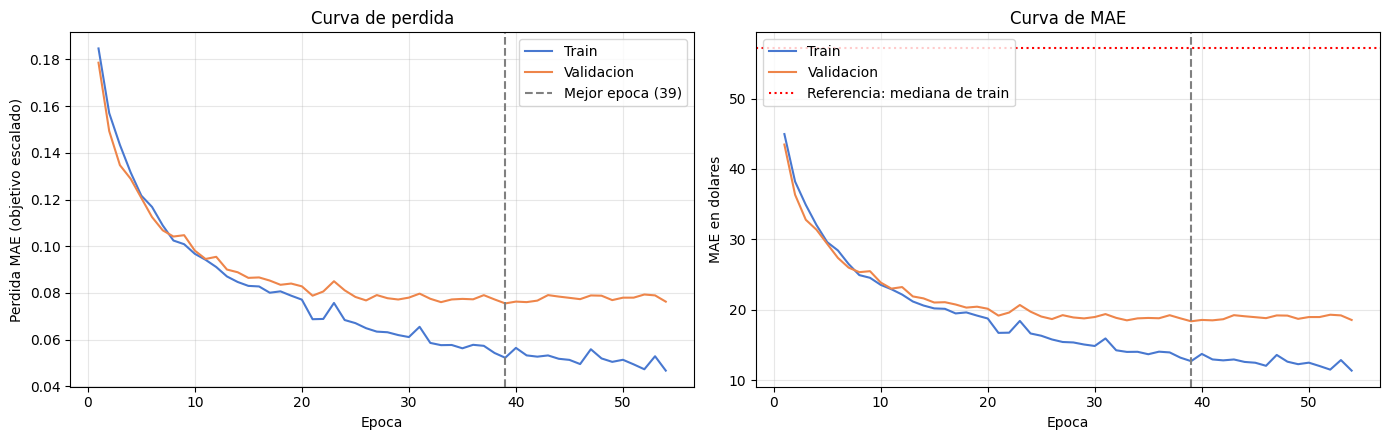

Parametros entrenables: 7809 (1.11 por fila de train)
Epocas entrenadas: 54, mejor epoca: 39
En la mejor epoca: MAE train 12.72, MAE val 18.38, brecha 5.66
En la ultima epoca: MAE train 11.37, MAE val 18.56, brecha 7.19
Minimo del MAE de val: 18.38 (epoca 39)


In [16]:
base_config = {'loss_name': 'mae', 'hidden_sizes': (64, 32), 'dropout': 0.0,
               'weight_decay': 0.0}
base_run = train_regressor(0, X_train, y_train, X_val, y_val, keep_history=True,
                           **base_config)
history = base_run['history']
best_epoch = base_run['best_epoch']
n_parameters = sum(p.numel() for p in base_run['model'].parameters())
epochs_axis = range(1, len(history['val_mae']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs_axis, history['train_loss'], label='Train')
axes[0].plot(epochs_axis, history['val_loss'], label='Validacion')
axes[0].axvline(best_epoch, color='gray', linestyle='--', label=f'Mejor epoca ({best_epoch})')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Perdida MAE (objetivo escalado)')
axes[0].set_title('Curva de perdida')
axes[0].legend()

axes[1].plot(epochs_axis, history['train_mae'], label='Train')
axes[1].plot(epochs_axis, history['val_mae'], label='Validacion')
axes[1].axhline(57.11, color='red', linestyle=':', label='Referencia: mediana de train')
axes[1].axvline(best_epoch, color='gray', linestyle='--')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MAE en dolares')
axes[1].set_title('Curva de MAE')
axes[1].legend()
plt.tight_layout()
plt.savefig('p3_04_curvas_base.png', dpi=110, bbox_inches='tight')
plt.show()

last = len(history['val_mae'])
print(f"Parametros entrenables: {n_parameters} ({n_parameters / len(y_train):.2f} por fila de train)")
print(f"Epocas entrenadas: {last}, mejor epoca: {best_epoch}")
print(f"En la mejor epoca: MAE train {history['train_mae'][best_epoch - 1]:.2f}, "
      f"MAE val {history['val_mae'][best_epoch - 1]:.2f}, "
      f"brecha {history['val_mae'][best_epoch - 1] - history['train_mae'][best_epoch - 1]:.2f}")
print(f"En la ultima epoca: MAE train {history['train_mae'][-1]:.2f}, "
      f"MAE val {history['val_mae'][-1]:.2f}, "
      f"brecha {history['val_mae'][-1] - history['train_mae'][-1]:.2f}")
print(f"Minimo del MAE de val: {min(history['val_mae']):.2f} (epoca {int(np.argmin(history['val_mae'])) + 1})")


La red base tiene 7809 parámetros, 1.11 por fila de train. Con la semilla 0
entrenó 54 épocas, y la mejor fue la 39, con un MAE de validación de 18.38.

**Lo que muestran las curvas.** Hasta la época 20 aproximadamente, el MAE de
train y el de validación bajan casi juntos. Después, la validación se estanca en
torno a 19, y el MAE de train sigue bajando, hasta 11 a 13. En la mejor
época, el MAE de train es 12.72 y el de validación 18.38, una brecha de 5.66.
En la última época, la brecha es 7.19 (11.37 frente a 18.56).

**Diagnóstico: hay sobreajuste moderado, y no hay subajuste.**

- *Sobreajuste*: el MAE de train es un 31% menor que el de validación en la
  mejor época. La brecha crece con las épocas mientras la validación no mejora.
- *Sin subajuste*: los dos MAE están muy por debajo de la referencia de la
  mediana (57.11). Incluso el de validación, 18.38, es un 68% menor.

La predicción se cumplió: se esperaba sobreajuste moderado.

**Cautela.** Es una sola semilla, y las curvas son ruidosas. Sirven para ver
la forma del problema. La comparación entre correcciones usa 10 semillas
(sección 5.2).

### 5.2 Corrección del sobreajuste

Si las curvas muestran sobreajuste, se prueban técnicas del apunte de la
Unidad 4. El Early Stopping ya está aplicado. Se prueban:

- **Dropout** de 0.1 y de 0.3, después de cada capa oculta.
- **Regularización L2**, con `weight_decay` de `1e-4`, `1e-3`, `3e-3` y `1e-2`
  en Adam.
- **Una red más chica**, de 32 -> 16 neuronas, para reducir la capacidad.

Se mide cada candidata con 10 semillas y dos protocolos, igual que en la sección 4.3. El principal para por el MAE de toda la validación. El control usa las mitades A y B.

**Regla de decisión, fijada antes de medir.** Se adopta la mejor candidata
solo si cumple dos condiciones:

1. Su MAE medio de validación mejora al de la red base en más de 2 errores
   estándar de la diferencia pareada.
2. El control de la mitad B también mejora, en el mismo sentido.

Si no las cumple, se mantiene la red base. Si una mejora no supera el ruido, decir que una corrección "ayudó" es un error.

**Aviso: se amplió la grilla después de ver un primer resultado.** Una primera
versión probaba L2 solo hasta `1e-3`. Ese fue el mejor valor, y la mejora
crecía con el valor. Un óptimo en el borde de la grilla es una señal de que el mejor valor real está más allá del borde. Por eso se agregaron `3e-3` y `1e-2`. La regla de
adopción no cambió. Como la grilla se amplió mirando la validación, la
selección final es algo optimista. El control de la mitad B ayuda a acotarlo.

In [17]:
def run_variant(x_train_matrix, x_val_matrix, seeds=SEEDS, **train_kwargs):
    # 10 corridas con parada por toda la validacion, y 10 con parada por la mitad A
    full = [train_regressor(seed, x_train_matrix, y_train, x_val_matrix, y_val,
                            **train_kwargs) for seed in seeds]
    half_a = [train_regressor(seed, x_train_matrix, y_train, x_val_matrix, y_val,
                              stop_idx=half_a_idx, **train_kwargs) for seed in seeds]
    return {'full': full, 'a': half_a}


def summarize_variants(results, base_name):
    # Tablas de metricas y de comparacion pareada con la variante base
    base_full = np.array([regression_metrics(y_val, r['prediction'])['MAE']
                          for r in results[base_name]['full']])
    base_b = np.array([np.abs(r['prediction'][half_b_idx] - y_val[half_b_idx]).mean()
                       for r in results[base_name]['a']])
    metric_rows, comparison_rows, stats = [], [], {}
    for name, runs in results.items():
        metrics = [regression_metrics(y_val, r['prediction']) for r in runs['full']]
        mae = np.array([m['MAE'] for m in metrics])
        b_mae = np.array([np.abs(r['prediction'][half_b_idx] - y_val[half_b_idx]).mean()
                          for r in runs['a']])
        diff, diff_b = mae - base_full, b_mae - base_b
        standard_error = diff.std(ddof=1) / np.sqrt(len(diff))
        stats[name] = {'mean_mae': mae.mean(), 'diff': diff.mean(), 'se': standard_error,
                       'diff_b': diff_b.mean()}
        metric_rows.append({
            'Variante': name,
            'Params': sum(p.numel() for p in runs['full'][0]['model'].parameters()),
            'MAE': mean_std(mae), 'RMSE': mean_std([m['RMSE'] for m in metrics]),
            'MedAE': mean_std([m['MedAE'] for m in metrics]),
            'R2': mean_std([m['R2'] for m in metrics], 3),
            'Epoca': f"{np.mean([r['best_epoch'] for r in runs['full']]):.0f}"})
        is_base = name == base_name
        comparison_rows.append({
            'Variante': name,
            'Dif. MAE vs base (EE)': '-' if is_base else
                f"{diff.mean():+.2f} ({standard_error:.2f})",
            'Mejor que base': '-' if is_base else f"{int((diff < 0).sum())}/{len(diff)}",
            'MAE en B (epoca de A)': mean_std(b_mae),
            'Dif. en B vs base (EE)': '-' if is_base else
                f"{diff_b.mean():+.2f} ({diff_b.std(ddof=1) / np.sqrt(len(diff_b)):.2f})"})
    return pd.DataFrame(metric_rows), pd.DataFrame(comparison_rows), stats


def apply_adoption_rule(stats, base_name):
    # Mejor candidata por MAE medio. Se adopta si mejora mas de 2 EE y la mitad B coincide
    candidates = {k: v for k, v in stats.items() if k != base_name}
    best_name = min(candidates, key=lambda k: candidates[k]['mean_mae'])
    best = candidates[best_name]
    adopt = best['diff'] < -2 * best['se'] and best['diff_b'] < 0
    return best_name, adopt


correction_candidates = {
    'Base (sin regularizar)': {},
    'Dropout 0.1': {'dropout': 0.1},
    'Dropout 0.3': {'dropout': 0.3},
    'L2 1e-4': {'weight_decay': 1e-4},
    'L2 1e-3': {'weight_decay': 1e-3},
    'L2 3e-3': {'weight_decay': 3e-3},
    'L2 1e-2': {'weight_decay': 1e-2},
    'Red 32-16': {'hidden_sizes': (32, 16)},
}
correction_results = {}
for name, changes in correction_candidates.items():
    if not changes:
        # La base es la configuracion 'MAE' de la seccion 4.3: se reusan esas 20 corridas
        correction_results[name] = loss_results['MAE']
    else:
        correction_results[name] = run_variant(X_train, X_val, **{**base_config, **changes})
check_run = train_regressor(0, X_train, y_train, X_val, y_val, **base_config)
assert np.array_equal(check_run['prediction'], loss_results['MAE']['full'][0]['prediction'])
print("Reuso verificado: la base reentrenada (semilla 0) da las mismas predicciones que 'MAE'\n")

metric_table, comparison_table, correction_stats = summarize_variants(
    correction_results, 'Base (sin regularizar)')
print("Validacion, 10 semillas, parada por el MAE de toda la validacion:")
print(metric_table.to_string(index=False))
print("\nComparacion pareada con la base, y control sin sesgo (mitad B):")
print(comparison_table.to_string(index=False))

best_name, adopt = apply_adoption_rule(correction_stats, 'Base (sin regularizar)')
stats = correction_stats[best_name]
print(f"\nMejor candidata: {best_name}, dif. {stats['diff']:+.2f} (2 EE = {2 * stats['se']:.2f}), "
      f"dif. en B {stats['diff_b']:+.2f}")
print(f"Se adopta la correccion segun la regla: {adopt}")
final_config = ({**base_config, **correction_candidates[best_name]} if adopt
                else dict(base_config))
final_name = best_name if adopt else 'Base (sin regularizar)'
print(f"Configuracion final: {final_name}")


Reuso verificado: la base reentrenada (semilla 0) da las mismas predicciones que 'MAE'

Validacion, 10 semillas, parada por el MAE de toda la validacion:
              Variante  Params           MAE          RMSE        MedAE             R2 Epoca
Base (sin regularizar)    7809 18.23 +- 0.47 56.28 +- 2.71 3.98 +- 0.41 0.915 +- 0.008    48
           Dropout 0.1    7809 18.10 +- 0.63 56.92 +- 3.86 3.56 +- 0.29 0.913 +- 0.012    46
           Dropout 0.3    7809 19.61 +- 0.44 61.57 +- 3.28 3.95 +- 0.21 0.898 +- 0.011    53
               L2 1e-4    7809 17.73 +- 0.35 56.79 +- 1.57 3.61 +- 0.48 0.914 +- 0.005    44
               L2 1e-3    7809 16.39 +- 0.25 54.23 +- 1.39 2.75 +- 0.09 0.921 +- 0.004    65
               L2 3e-3    7809 17.20 +- 0.34 61.80 +- 2.64 2.62 +- 0.20 0.898 +- 0.009    58
               L2 1e-2    7809 22.19 +- 0.26 96.22 +- 0.90 2.91 +- 0.18 0.752 +- 0.005    64
             Red 32-16    3393 18.39 +- 0.58 60.29 +- 3.95 3.40 +- 0.26 0.902 +- 0.013    54

Comparac

| Variante | MAE de validación | Dif. vs base (EE) | Mejor que base | Dif. en la mitad B (EE) |
|---|---|---|---|---|
| Base (sin regularizar) | 18.23 +- 0.47 | - | - | - |
| Dropout 0.1 | 18.10 +- 0.63 | -0.14 (0.19) | 6/10 | -0.38 (0.15) |
| Dropout 0.3 | 19.61 +- 0.44 | +1.38 (0.16) | 0/10 | +1.18 (0.39) |
| L2 1e-4 | 17.73 +- 0.35 | -0.50 (0.18) | 9/10 | -0.58 (0.25) |
| **L2 1e-3** | **16.39 +- 0.25** | **-1.84 (0.15)** | **10/10** | **-1.64 (0.28)** |
| L2 3e-3 | 17.20 +- 0.34 | -1.04 (0.22) | 9/10 | -1.53 (0.31) |
| L2 1e-2 | 22.19 +- 0.26 | +3.95 (0.13) | 0/10 | +0.76 (0.26) |
| Red 32-16 | 18.39 +- 0.58 | +0.16 (0.22) | 4/10 | +0.09 (0.37) |

**Decisión: se adopta L2 con `weight_decay = 1e-3`.** La mejora es de -1.84, unos
12 errores estándar, y el umbral de la regla era 0.29 (2 errores estándar).
Es mejor en las 10 semillas, y la mitad B, que no participó en la elección,
coincide (-1.64). La regla se cumple. El MAE baja un 10.1%.

**El óptimo de L2 es interior.** Al ampliar la grilla, el MAE depende así del valor de L2. Es 17.73 con
`1e-4`, 16.39 con `1e-3`, 17.20 con `3e-3` y 22.19 con `1e-2`. Forma una U, con el mínimo en `1e-3`. Con `1e-2` la red ya
subajusta: el R2 cae a 0.752 y el RMSE sube a 96.22. La sospecha de que el
mejor valor estaba fuera de la grilla no se confirmó.

**Efecto de L2 sobre las otras métricas.** Con `1e-3`, la MedAE baja de 3.98 a
2.75, el RMSE de 56.28 a 54.23, y el R2 sube de 0.915 a 0.921. Mejoran todas.
Con `3e-3`, el RMSE empeora (61.80) mientras la MedAE sigue mejorando (2.62).
Una penalización más fuerte favorece a las transacciones típicas y perjudica a los
grandes.

**Lo que no funcionó.** Dropout 0.3 empeora el resultado (+1.38, en 0 de las
10 semillas). Dropout 0.1 casi no cambia el MAE de validación (-0.14, menos de
1 error estándar). La mitad B muestra una mejora chica (-0.38), pero el
protocolo principal no la confirma. Reducir la red a 32-16 no cambia nada
(+0.16). El Dropout no ayuda en este problema.

**Alcance.** Son 10 semillas y una sola división. La grilla se amplió después
de ver un primer resultado, así que la elección final es algo optimista. La
mitad B da una estimación menos sesgada de la mejora (-1.64).

### 5.3 Curvas antes y después de la corrección

Si se adoptó una corrección, se comparan las curvas de la red base con las de
la red corregida, con la misma semilla. Si no se adoptó ninguna, se
indica, y la red final es la red base.

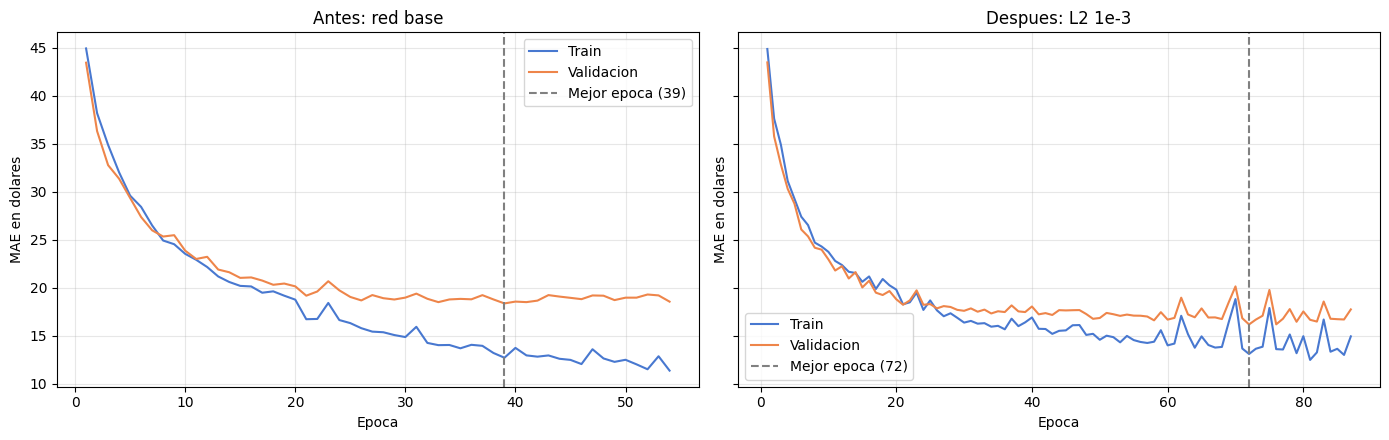

Antes: mejor epoca 39, MAE train 12.72, MAE val 18.38, brecha 5.66
Despues: mejor epoca 72, MAE train 13.11, MAE val 16.19, brecha 3.08


In [18]:
if final_name == 'Base (sin regularizar)':
    print("No se adopto ninguna correccion: la red final es la red base.")
    print("Las curvas son las de la seccion 5.1.")
else:
    corrected_run = train_regressor(0, X_train, y_train, X_val, y_val,
                                    keep_history=True, **final_config)
    corrected_history = corrected_run['history']
    corrected_best = corrected_run['best_epoch']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
    for ax, run_history, run_best, title in [
            (axes[0], history, best_epoch, 'Antes: red base'),
            (axes[1], corrected_history, corrected_best, f'Despues: {final_name}')]:
        epochs_range = range(1, len(run_history['val_mae']) + 1)
        ax.plot(epochs_range, run_history['train_mae'], label='Train')
        ax.plot(epochs_range, run_history['val_mae'], label='Validacion')
        ax.axvline(run_best, color='gray', linestyle='--', label=f'Mejor epoca ({run_best})')
        ax.set_xlabel('Epoca')
        ax.set_ylabel('MAE en dolares')
        ax.set_title(title)
        ax.legend()
    plt.tight_layout()
    plt.savefig('p3_05_curvas_antes_despues.png', dpi=110, bbox_inches='tight')
    plt.show()
    for label, run_history, run_best in [('Antes', history, best_epoch),
                                          ('Despues', corrected_history, corrected_best)]:
        gap = run_history['val_mae'][run_best - 1] - run_history['train_mae'][run_best - 1]
        print(f"{label}: mejor epoca {run_best}, MAE train "
              f"{run_history['train_mae'][run_best - 1]:.2f}, MAE val "
              f"{run_history['val_mae'][run_best - 1]:.2f}, brecha {gap:.2f}")


Con la semilla 0, la corrección cambia la forma de las curvas:

| | Mejor época | MAE de train | MAE de validación | Brecha |
|---|---|---|---|---|
| Antes (red base) | 39 | 12.72 | 18.38 | 5.66 |
| Después (L2 1e-3) | 72 | 13.11 | 16.19 | 3.08 |

La brecha baja de 5.66 a 3.08, un 46% menos. El MAE de validación mejora en
2.2 puntos. El MAE de train sube de 12.72 a 13.11: la red ajusta menos los
datos de entrenamiento, que es lo esperado con regularización. En el gráfico
de la derecha, train y validación van juntos hasta la época 25
aproximadamente. Después, la validación baja despacio y con oscilaciones, y la
mejor época llega más tarde (72 frente a 39).

Es una sola semilla. El resultado general es el de la sección 5.2, con 10
semillas: una mejora media de 1.84 en el MAE de validación.

### 5.4 Ablación de preprocesamiento y de arquitectura

En la sección 3 se dejaron dos decisiones de preprocesamiento para medir cuando
hubiera un modelo. Además, la consigna pide justificar la arquitectura (3c),
y hasta ahora la arquitectura solo se eligió. Se miden:

- **El escalador de las variables numéricas**: `RobustScaler` (la decisión de
  partida), `StandardScaler`, y `log1p` sobre `Sales` más `StandardScaler`. La
  asimetría de `Sales` (14.19) no tenía un ganador claro. Cada variante cambia
  el escalador de las 9 variables numéricas a la vez, no solo el de `Sales`.
- **La variable `State`**: 48 columnas one-hot, algunas con pocas filas por
  estado. Se compara con el modelo sin ella.
- **El tamaño de la red**: 64-32 (la de partida), 32-16 y 128-64.

Se mide cada variante con la configuración final de la sección 5.2, con 10
semillas y los dos protocolos. Se usa la misma regla de adopción. Una variante reemplaza a la de partida solo si mejora el MAE en más de 2 errores estándar pareados, y la mitad B coincide. Si alguna se adopta, el notebook
reconstruye las matrices y la configuración con ella.

**Predicción, escrita antes de medir.** Para `State` se espera que no haya
diferencia medible, como la imputación de `bmi` del Problema 1. Para el
escalador no hay una predicción: `log1p` corrige la asimetría, pero
cambia la relación entre `Sales` y `Profit`, que es casi proporcional. Para el
tamaño, el Problema 2 mostró un efecto hacia abajo pero no hacia arriba, y no
se sabe si aquí pasa lo mismo.

In [19]:
all_categorical = list(categorical_features)
no_state = [column for column in categorical_features if column != 'State']
# nombre -> (escalador, variables categoricas, cambios de configuracion)
preprocessing_specs = {
    'RobustScaler (base)': ('robust', all_categorical, {}),
    'StandardScaler': ('standard', all_categorical, {}),
    'log1p(Sales) + StandardScaler': ('log_standard', all_categorical, {}),
    'Sin State': ('robust', no_state, {}),
    'Red 32-16': ('robust', all_categorical, {'hidden_sizes': (32, 16)}),
    'Red 128-64': ('robust', all_categorical, {'hidden_sizes': (128, 64)}),
}
preprocessing_results = {}
for name, (scaler_kind, categorical, changes) in preprocessing_specs.items():
    train_matrix, val_matrix, _test_matrix, _names = build_matrices(scaler_kind, categorical)
    if name == 'RobustScaler (base)':
        # Mismas matrices y misma configuracion que la correccion elegida en la seccion 5.2
        assert np.array_equal(train_matrix, X_train) and np.array_equal(val_matrix, X_val)
        preprocessing_results[name] = correction_results[final_name]
    else:
        preprocessing_results[name] = run_variant(train_matrix, val_matrix,
                                                  **{**final_config, **changes})

metric_table_p, comparison_table_p, preprocessing_stats = summarize_variants(
    preprocessing_results, 'RobustScaler (base)')
print("Validacion, 10 semillas, parada por el MAE de toda la validacion:")
print(metric_table_p.to_string(index=False))
print("\nComparacion pareada con la base, y control sin sesgo (mitad B):")
print(comparison_table_p.to_string(index=False))

# log1p frente a StandardScaler: las dos usan StandardScaler en las otras 8 variables
_, log_comparison, _ = summarize_variants(
    {name: preprocessing_results[name] for name in ('StandardScaler', 'log1p(Sales) + StandardScaler')},
    'StandardScaler')
print("\nEfecto de log1p sobre Sales, con StandardScaler en las 9 variables numericas en los dos casos:")
print(log_comparison.to_string(index=False))

best_name_p, adopt_p = apply_adoption_rule(preprocessing_stats, 'RobustScaler (base)')
stats_p = preprocessing_stats[best_name_p]
print(f"\nMejor variante: {best_name_p}, dif. {stats_p['diff']:+.2f} "
      f"(2 EE = {2 * stats_p['se']:.2f}), dif. en B {stats_p['diff_b']:+.2f}")
print(f"Reemplaza a la base segun la regla: {adopt_p}")

# Decisiones finales del pipeline, con la variante adoptada si la hubo
chosen_name = best_name_p if adopt_p else 'RobustScaler (base)'
final_scaler_kind, final_categorical, config_changes = preprocessing_specs[chosen_name]
final_config = {**final_config, **config_changes}
X_train, X_val, X_test, feature_names = build_matrices(final_scaler_kind, final_categorical)
print(f"\nPipeline final: {chosen_name}, configuracion {final_config}")
print(f"Entradas: {X_train.shape[1]}")


Validacion, 10 semillas, parada por el MAE de toda la validacion:
                     Variante  Params           MAE          RMSE        MedAE             R2 Epoca
          RobustScaler (base)    7809 16.39 +- 0.25 54.23 +- 1.39 2.75 +- 0.09 0.921 +- 0.004    65
               StandardScaler    7809 17.92 +- 0.49 56.52 +- 2.16 3.96 +- 0.28 0.914 +- 0.007    64
log1p(Sales) + StandardScaler    7809 18.30 +- 0.66 68.30 +- 5.14 2.57 +- 0.30 0.875 +- 0.020    65
                    Sin State    4737 16.13 +- 0.42 53.28 +- 3.02 2.53 +- 0.18 0.924 +- 0.009    66
                    Red 32-16    3393 16.82 +- 0.35 56.09 +- 2.41 2.71 +- 0.20 0.916 +- 0.007    68
                   Red 128-64   19713 16.57 +- 0.36 53.85 +- 1.47 2.93 +- 0.22 0.922 +- 0.004    52

Comparacion pareada con la base, y control sin sesgo (mitad B):
                     Variante Dif. MAE vs base (EE) Mejor que base MAE en B (epoca de A) Dif. en B vs base (EE)
          RobustScaler (base)                     -      

| Variante | MAE de validación | Dif. vs base (EE) | Mejor que base | Dif. en la mitad B (EE) |
|---|---|---|---|---|
| **RobustScaler (base)** | **16.39 +- 0.25** | - | - | - |
| StandardScaler | 17.92 +- 0.49 | +1.53 (0.18) | 0/10 | +1.49 (0.27) |
| `log1p(Sales)` + StandardScaler | 18.30 +- 0.66 | +1.91 (0.22) | 0/10 | +0.84 (0.22) |
| Sin `State` | 16.13 +- 0.42 | -0.26 (0.16) | 7/10 | -0.34 (0.31) |
| Red 32-16 | 16.82 +- 0.35 | +0.42 (0.14) | 2/10 | +0.28 (0.27) |
| Red 128-64 | 16.57 +- 0.36 | +0.17 (0.18) | 4/10 | +0.30 (0.16) |

**Ninguna variante reemplaza a la base según la regla.** La mejor por MAE es
"Sin `State`" (-0.26). Su mejora es de 1.6 errores estándar, y la regla pide
más de 2.

**Escalador: `RobustScaler` es mejor que `StandardScaler`.** `StandardScaler` es
peor por 1.53 (un 9%), en las 10 semillas, y la mitad B lo confirma (+1.49).
La variante cambia el escalador de las 9 variables numéricas, no solo el de
`Sales`. Por eso la medición no prueba el argumento de la sección 3.5, que
miraba solo `Sales`.

**`log1p(Sales)`: el efecto propio no es claro.** Frente a la base, la variante es peor en el MAE (+1.91). Es mucho peor en el RMSE (68.30 frente a 54.23, con R2 0.875 frente a 0.921). Pero su MedAE es menor que la de la base (2.57 frente a 2.75). La
variante cambia dos cosas: aplica `log1p` a `Sales` y usa `StandardScaler` en
las otras 8 variables. Para aislar `log1p`, la variante se compara con `StandardScaler`,
que usa el mismo escalador en las otras 8. Con toda la validación, `log1p` es
peor por 0.38 (error estándar 0.23, mejor en 2 de 10 semillas). En la mitad B
es mejor por 0.65 (error estándar 0.26). Los dos protocolos no coinciden, así
que no se afirma un efecto de `log1p` solo. La idea de que `log1p` rompe la
proporción entre `Sales` y `Profit` queda sin probar.

**`State`: sin diferencia que se pueda afirmar.** Sin la variable, el MAE es 16.13 y es mejor en 7 de las 10 semillas. En la
mitad B la mejora es de 0.34 (1.1 errores estándar). Ninguno de los dos protocolos supera el umbral.
Es el resultado que se predijo (sin diferencia medible), aunque la tendencia
favorece quitarla. Sin `State`, la red tiene 4737 parámetros, un 39% menos.
Por la regla, la variable se mantiene.

**Arquitectura: 64-32 está cerca de la meseta.** La red de 32-16 es un poco
peor (+0.42, unos 3 errores estándar, mejor en 2 de 10 semillas). La de 128-64, con 2.5 veces los
parámetros, no mejora (+0.17). Es el mismo patrón del Problema 2: achicar
cuesta algo, y agrandar no gana.

**Pipeline final.** `RobustScaler` y todas las variables categóricas (88 entradas). MLP de 64-32
con salida lineal. Función de costo MAE, L2 con `weight_decay = 1e-3`, Adam
con tasa `1e-3`, batches de 64, y parada por el MAE de validación.

**Alcance.** Son 10 semillas y una sola división de datos. Una diferencia menor que 2 errores estándar no se distingue del ruido de las semillas. En esta tabla, eso es de 0.3 a 0.4 dólares de MAE.

## 6. Evaluación del modelo en test

### 6.1 Métricas en dólares, con intervalos de confianza

Esta sección evalúa el modelo final de la sección 5 sobre test. El modelo es un MLP de
64-32, función de costo MAE, L2 con `weight_decay = 1e-3`. Se usa la semilla
0, que se fijó antes de ver ningún resultado de test.

**Por qué intervalos de confianza.** La sección 3.3 mostró que test tiene
solo 4 de las 20 filas más extremas de `Profit`. Un solo número de MAE o de
RMSE no dice cuánto depende de esas pocas filas.

**Qué es el bootstrap.** El *bootstrap* (o *bootstrapping*) es una técnica de
remuestreo. Se sacan muchas muestras nuevas, **con reposición**, de los datos
de test existentes. Para cada muestra se recalcula la métrica. La
dispersión de esos valores indica cuánta incertidumbre tiene la métrica. No
supone ninguna forma para la distribución del error, y eso sirve para
`Profit`, que tiene colas pesadas.

Decisiones del bootstrap:

- **10000 remuestreos.** Con menos, los percentiles de las colas son poco
  estables.
- **Se remuestrean pedidos enteros**, no filas sueltas. Las filas de un pedido
  comparten cliente, fechas y estado. La sección 6.2 mide si esto cambia el
  resultado.
- **Intervalo de 95%**: percentiles 2.5 y 97.5 de las 10000 métricas.
- Se reportan el valor observado, la media y el desvío del bootstrap, y el
  intervalo.

Como referencia, también se evalúan los dos predictores constantes de la
sección 4.2 (mediana y media de train).

In [20]:
FINAL_SEED = 0
training_start = time.perf_counter()
final_run = train_regressor(FINAL_SEED, X_train, y_train, X_val, y_val, **final_config)
mlp_training_seconds = time.perf_counter() - training_start
final_model = final_run['model']


def predict_dollars(model, features):
    model.eval()
    with torch.no_grad():
        return to_dollars(model(torch.from_numpy(features).to(DEVICE)).cpu().numpy())


# Unica evaluacion del modelo final sobre test
test_prediction = predict_dollars(final_model, X_test)

# Bootstrap por pedidos: cada remuestreo elige pedidos de test con reposicion
BOOTSTRAP_SAMPLES = 10_000
test_groups = groups[test_idx]
unique_orders = np.unique(test_groups)
rows_by_order = [np.where(test_groups == order)[0] for order in unique_orders]
bootstrap_rng = np.random.default_rng(SEED)
bootstrap_indices = []
for _ in range(BOOTSTRAP_SAMPLES):
    sampled_orders = bootstrap_rng.integers(0, len(unique_orders), size=len(unique_orders))
    bootstrap_indices.append(
        np.concatenate([rows_by_order[i] for i in sampled_orders]).astype(np.int32))


def metrics_with_large(y_true, y_pred):
    # Metricas en dolares, y el MAE separado por transacciones grandes y tipicos
    result = regression_metrics(y_true, y_pred)
    large = np.abs(y_true) > 100
    result['MAE |y|>100'] = np.abs(y_true[large] - y_pred[large]).mean() if large.any() else np.nan
    result['MAE |y|<=100'] = np.abs(y_true[~large] - y_pred[~large]).mean()
    return result


def bootstrap_metrics(y_true, y_pred, indices):
    return pd.DataFrame([metrics_with_large(y_true[idx], y_pred[idx]) for idx in indices])


def summary_table(y_true, y_pred, indices, metric_names):
    observed = metrics_with_large(y_true, y_pred)
    draws = bootstrap_metrics(y_true, y_pred, indices)
    rows = []
    for name in metric_names:
        low, high = np.percentile(draws[name], [2.5, 97.5])
        rows.append({'metrica': name, 'observado': observed[name],
                     'media_boot': draws[name].mean(), 'std_boot': draws[name].std(),
                     'ic95_bajo': low, 'ic95_alto': high})
    return pd.DataFrame(rows).set_index('metrica'), draws


metric_names = ['MAE', 'RMSE', 'MedAE', 'R2', 'sesgo', 'MAE |y|>100', 'MAE |y|<=100']
mlp_summary, mlp_draws = summary_table(y_test, test_prediction, bootstrap_indices, metric_names)
print("MLP final (semilla 0) sobre test, bootstrap por pedidos (10000):")
print(mlp_summary.round(3).to_string())

print("\nReferencias sobre test (predictores constantes de train):")
for name, value in [('mediana de train', np.median(y_train)), ('media de train', y_train.mean())]:
    reference_summary, _ = summary_table(y_test, np.full_like(y_test, value),
                                         bootstrap_indices, ['MAE', 'RMSE', 'MedAE', 'R2'])
    print(f"-- {name} --")
    print(reference_summary.round(3).to_string())
print(f"\nTest: {len(y_test)} filas, {len(unique_orders)} pedidos, "
      f"{int((np.abs(y_test) > 100).sum())} filas con |Profit| > 100")


MLP final (semilla 0) sobre test, bootstrap por pedidos (10000):
              observado  media_boot  std_boot  ic95_bajo  ic95_alto
metrica                                                            
MAE           17.077000   17.073999     1.769     13.998     20.864
RMSE          70.484001   68.834000    14.989     38.182     97.691
MedAE          2.945000    2.948000     0.165      2.640      3.307
R2             0.903000    0.895000     0.043      0.804      0.965
sesgo          3.509000    3.500000     1.737      0.425      7.226
MAE |y|>100   74.461998   74.512001    12.401     53.176    101.477
MAE |y|<=100   8.279000    8.276000     0.469      7.387      9.222

Referencias sobre test (predictores constantes de train):
-- mediana de train --
          observado  media_boot  std_boot  ic95_bajo  ic95_alto
metrica                                                        
MAE       59.941002   59.945000     5.742     49.615     72.500
RMSE     227.173004  222.873001    43.219    143.

**Resultado del MLP final sobre test (semilla 0).**

| Métrica | Observado | IC95 por pedidos |
|---|---|---|
| MAE | 17.08 | [14.00, 20.86] |
| RMSE | 70.48 | [38.18, 97.69] |
| MedAE | 2.95 | [2.64, 3.31] |
| R2 | 0.903 | [0.804, 0.965] |
| Sesgo (predicho - real) | +3.51 | [+0.42, +7.23] |
| MAE con `\|Profit\|` > 100 (201 filas) | 74.46 | [53.18, 101.48] |
| MAE con `\|Profit\|` <= 100 | 8.28 | [7.39, 9.22] |

**Contra la referencia.** El predictor constante de la mediana de train tiene un
MAE de 59.94 (IC95 [49.62, 72.50]) y un R2 de -0.011. Los intervalos no se
superponen: el MLP reduce el MAE en un 72%.

**Qué intervalos son estrechos y cuáles no.** El MAE tiene un intervalo
razonable, de ancho 6.9. El RMSE tiene un intervalo enorme, de 38.18 a 97.69,
y el R2 va de 0.80 a 0.96. Esas dos métricas dependen de pocas filas extremas
(sección 7.1: 10 filas explican el 83% del error cuadrático). El MAE es la
métrica estable, y por eso es la principal.

**Sesgo.** El modelo sobreestima en promedio 3.51 dólares por transacción. El
intervalo no contiene el 0, así que el sesgo positivo es real. Es chico frente
al MAE (17.08).

**Transacciones grandes y típicas.** El MAE es 74.46 con `|Profit|` mayor que 100 y 8.28
con `|Profit|` menor o igual que 100, unas 9 veces más. Las transacciones grandes son
el 13.3% de las filas de test.

**Frente a validación.** El MAE de validación del modelo final (media de 10
semillas) es 16.39. En test es 17.08 con la semilla 0, y 17.68 en promedio de
10 semillas. Test da un valor algo mayor, dentro del intervalo. Una parte de
la diferencia es el optimismo de la validación, que se usó para elegir.

### 6.2 Dos comprobaciones del bootstrap: por filas y por semillas

**Bootstrap por pedidos o por filas.** Muchos análisis remuestrean filas
sueltas. Aquí se remuestrean pedidos, por la razón de la sección 6.1.
Se comparan los dos. **Predicción, escrita antes de medir:** se esperaba que el
bootstrap por filas diera intervalos más angostos, porque ignora que las filas
de un pedido se parecen.

**Variabilidad por semilla.** El modelo final usa la semilla 0. También se entrenan
las semillas 1 a 9, y cada una se mide sobre test. No se elige entre
ellas: es solo una descripción de cuánto cambia el resultado con la
inicialización.

In [21]:
# Bootstrap por filas, con el mismo numero de remuestreos
row_rng = np.random.default_rng(SEED + 1)
row_indices = [row_rng.integers(0, len(y_test), size=len(y_test)).astype(np.int32)
               for _ in range(BOOTSTRAP_SAMPLES)]
rows_summary, _ = summary_table(y_test, test_prediction, row_indices, metric_names)

comparison = pd.DataFrame({
    'IC95 por pedidos': [f"[{mlp_summary.loc[m, 'ic95_bajo']:.2f}, {mlp_summary.loc[m, 'ic95_alto']:.2f}]"
                         for m in metric_names],
    'ancho por pedidos': [mlp_summary.loc[m, 'ic95_alto'] - mlp_summary.loc[m, 'ic95_bajo']
                          for m in metric_names],
    'IC95 por filas': [f"[{rows_summary.loc[m, 'ic95_bajo']:.2f}, {rows_summary.loc[m, 'ic95_alto']:.2f}]"
                       for m in metric_names],
    'ancho por filas': [rows_summary.loc[m, 'ic95_alto'] - rows_summary.loc[m, 'ic95_bajo']
                        for m in metric_names],
}, index=metric_names)
comparison['ancho filas / pedidos'] = comparison['ancho por filas'] / comparison['ancho por pedidos']
print("Bootstrap por pedidos y por filas:")
print(comparison.round(3).to_string())
orders_sizes = pd.Series(test_groups).value_counts()
print(f"\nFilas por pedido en test: media {orders_sizes.mean():.2f}, maximo {orders_sizes.max()}")

# Variabilidad por semilla, sobre test (descriptivo)
# Son las 10 corridas del pipeline final de la seccion 5.4: no se reentrenan
seed_runs = preprocessing_results[chosen_name]['full']
assert np.array_equal(seed_runs[FINAL_SEED]['prediction'], final_run['prediction'])
seed_metrics = [regression_metrics(y_test, predict_dollars(seed_run['model'], X_test))
                for seed_run in seed_runs]
seed_table = pd.DataFrame(seed_metrics)
print("\nMetricas de test de las 10 semillas (descriptivo):")
print(seed_table[['MAE', 'RMSE', 'MedAE', 'R2']].agg(['mean', 'std', 'min', 'max']).round(3).to_string())
print(f"Semilla 0 (modelo final): MAE {seed_table['MAE'][0]:.2f}, RMSE {seed_table['RMSE'][0]:.2f}")
print(f"Ranking de la semilla 0 por MAE (1 = mejor): "
      f"{int((seed_table['MAE'] < seed_table['MAE'][0]).sum()) + 1} de {len(SEEDS)}")


Bootstrap por pedidos y por filas:
             IC95 por pedidos  ancho por pedidos   IC95 por filas  ancho por filas  ancho filas / pedidos
MAE            [14.00, 20.86]              6.866   [13.94, 20.84]            6.902                  1.005
RMSE           [38.18, 97.69]             59.509   [38.55, 98.33]           59.777                  1.005
MedAE            [2.64, 3.31]              0.666     [2.67, 3.29]            0.623                  0.935
R2               [0.80, 0.96]              0.160     [0.81, 0.97]            0.160                  0.999
sesgo            [0.42, 7.23]              6.801     [0.35, 7.32]            6.971                  1.025
MAE |y|>100   [53.18, 101.48]             48.302  [53.52, 100.60]           47.083                  0.975
MAE |y|<=100     [7.39, 9.22]              1.835     [7.40, 9.23]            1.831                  0.998

Filas por pedido en test: media 2.01, maximo 11

Metricas de test de las 10 semillas (descriptivo):
         MAE    

**La predicción falló: los dos bootstrap dan casi el mismo intervalo.** Se esperaba
que el bootstrap por filas diera intervalos más angostos. El cociente entre
los anchos es 1.005 para el MAE, 1.005 para el RMSE, 0.935 para la MedAE y 0.999
para el R2. Los pedidos de test tienen 2.01 filas en promedio (máximo 11), y
los errores de las filas de un mismo pedido casi no se parecen. En este
dataset, remuestrear por pedidos es una precaución que no cambia el
resultado. El remuestreo por pedidos se mantiene porque es lo correcto en principio.
No se presenta como una corrección necesaria.

**Variabilidad por semilla.** En test, las 10 semillas dan un MAE medio de 17.68 (desvío 0.56, de 17.06 a 18.99). El RMSE medio es 75.35 (desvío 6.36), y el R2 medio 0.888 (desvío 0.019). La semilla 0 es la segunda mejor de las 10 en MAE
(puesto 2 de 10). Esta semilla se fijó antes de ver resultados, así que no se
eligió por ser buena. Su MAE (17.08) es algo menor que el típico, que es 17.68.

La variación por semilla (0.56) es chica frente al ancho del intervalo por
datos (6.9). La incertidumbre principal viene de los datos de test, y no del
entrenamiento.

### 6.3 Qué significa el error en dólares

El enunciado pide interpretar las métricas en términos del negocio. Se miran
cuatro cosas:

- **El error típico por transacción**, contra el `Profit` típico de una transacción.
- **La distribución del error**: cuántas transacciones tienen errores chicos y
  cuántas grandes.
- **El total**: si se suma el `Profit` de todas las transacciones de test, cuánto
  se equivoca el modelo. Sirve para una proyección global de ganancias.
- **Las transacciones con pérdida**: si el modelo detecta las transacciones con `Profit` negativo, que son las que el negocio quiere evitar.

In [22]:
abs_error = np.abs(y_test - test_prediction)
print(f"Profit por transaccion en test: media {y_test.mean():.2f}, mediana {np.median(y_test):.2f}")
print(f"MAE {mlp_summary.loc['MAE', 'observado']:.2f} = "
      f"{mlp_summary.loc['MAE', 'observado'] / y_test.mean() * 100:.0f}% del Profit medio")
print(f"MedAE {mlp_summary.loc['MedAE', 'observado']:.2f} = "
      f"{mlp_summary.loc['MedAE', 'observado'] / np.median(y_test) * 100:.0f}% del Profit mediano")

percentiles = [50, 75, 90, 95, 99, 100]
print("\nError absoluto por transaccion (percentiles 50, 75, 90, 95, 99 y maximo):")
print({int(p): round(float(v), 1) for p, v in zip(percentiles, np.percentile(abs_error, percentiles))})
for threshold in (10, 25, 50, 100):
    print(f"  transacciones con error menor que {threshold} dolares: "
          f"{(abs_error < threshold).mean() * 100:.1f}%")

total_actual, total_predicted = y_test.sum(), test_prediction.sum()
total_error_pct = (total_predicted - total_actual) / total_actual * 100
bootstrap_total = np.array([(test_prediction[i].sum() - y_test[i].sum()) / y_test[i].sum() * 100
                            for i in bootstrap_indices])
low_total, high_total = np.percentile(bootstrap_total, [2.5, 97.5])
print(f"\nProfit total real en test: {total_actual:,.0f}, predicho: {total_predicted:,.0f}")
print(f"Diferencia: {total_predicted - total_actual:+,.0f} ({total_error_pct:+.1f}%), "
      f"IC95 [{low_total:+.1f}%, {high_total:+.1f}%]")

actual_loss, predicted_loss = y_test < 0, test_prediction < 0
true_positive = (actual_loss & predicted_loss).sum()
print(f"\nTransacciones con perdida en test: {actual_loss.sum()} ({actual_loss.mean() * 100:.1f}%)")
print(f"  el modelo detecta {true_positive / actual_loss.sum() * 100:.1f}% (recall)")
print(f"  de los que marca como perdida, acierta {true_positive / predicted_loss.sum() * 100:.1f}% (precision)")
print(f"  coincidencia de signo en todas las transacciones: "
      f"{((y_test > 0) == (test_prediction > 0)).mean() * 100:.1f}%")


Profit por transaccion en test: media 32.28, mediana 9.34
MAE 17.08 = 53% del Profit medio
MedAE 2.95 = 32% del Profit mediano

Error absoluto por transaccion (percentiles 50, 75, 90, 95, 99 y maximo):
{50: 2.9, 75: 12.4, 90: 38.6, 95: 68.9, 99: 177.2, 100: 1526.8}
  transacciones con error menor que 10 dolares: 72.8%
  transacciones con error menor que 25 dolares: 85.1%
  transacciones con error menor que 50 dolares: 92.3%
  transacciones con error menor que 100 dolares: 97.2%

Profit total real en test: 48,805, predicho: 54,112
Diferencia: +5,306 (+10.9%), IC95 [+1.2%, +29.5%]

Transacciones con perdida en test: 275 (18.2%)
  el modelo detecta 84.0% (recall)
  de los que marca como perdida, acierta 86.2% (precision)
  coincidencia de signo en todas las transacciones: 94.6%


**Error típico.** El MAE (17.08) es el 53% del `Profit` medio por transacción
(32.28). La MedAE (2.95) es el 32% del `Profit` mediano (9.34).

**Distribución del error.** La mitad de las transacciones tiene un error menor o igual
que 2.9 dólares. El 72.8% tiene un error menor que 10 dólares, el 85.1% menor
que 25, el 92.3% menor que 50 y el 97.2% menor que 100. El percentil 99 es
177.2 dólares, y el máximo es 1526.8.

**Total.** El `Profit` total real de test es 48805 dólares, y el predicho 54112:
una diferencia de +5306 (+10.9%). El intervalo de 95% va de +1.2% a +29.5%. El
modelo sobreestima el total, y el intervalo no contiene el 0. El intervalo es muy
ancho por las transacciones extremas. Para una proyección global de ganancias, la precisión es baja: el límite alto del intervalo es una sobreestimación de casi un 30%.

**Transacciones con pérdida.** Test tiene 275 transacciones con `Profit` negativo (18.2%). El
modelo detecta el 84.0% de ellas (recall). De las transacciones que marca como
pérdida, el 86.2% lo es de verdad (precisión). El signo del `Profit` coincide
en el 94.6% de las transacciones.

**Lectura para el negocio.** El modelo estima el `Profit` de una transacción típica con
un error de pocos dólares. Detecta más de cuatro de cada cinco transacciones con pérdida. No estima bien las transacciones más grandes: ahí los errores son de
cientos de dólares (sección 7).

## 7. Análisis de residuos

### 7.1 El error según la magnitud del `Profit`

Se grafica el residuo, `Profit real - Profit predicho`, contra el `Profit` real.
Un modelo que falla por igual en todas las transacciones da una banda horizontal de ancho constante. Se usa escala `symlog` porque los
valores van de -3400 a 5040.

Después se agrupan las transacciones por `|Profit|` y se mide el error de cada grupo.
Así se responde si el error es constante, o si el modelo falla en las transacciones de gran magnitud. También se mide cuánto del error total viene de las filas
peor predichas.

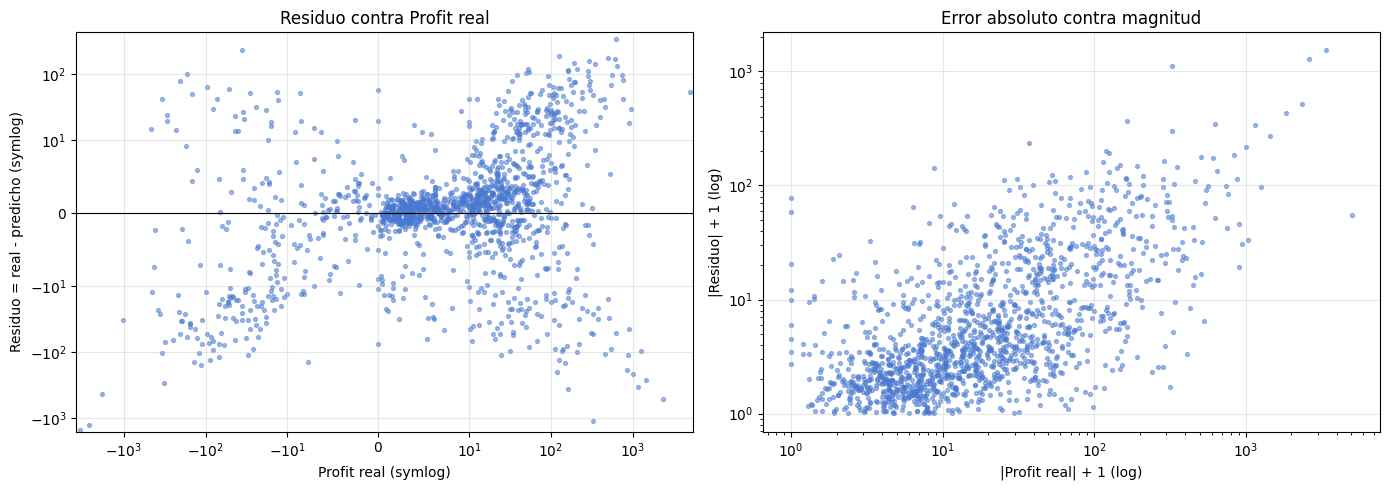

      |Profit|  filas  % de filas        MAE  residuo medio  MAE / |Profit| medio  % del error total
    [0.0, 5.0)    352       23.28   2.700000      -0.500000                  1.03           3.670000
   [5.0, 20.0)    510       33.73   5.220000      -0.630000                  0.48          10.320000
  [20.0, 50.0)    300       19.84  13.610000       0.220000                  0.42          15.820000
 [50.0, 100.0)    149        9.85  21.190001       1.310000                  0.30          12.230000
[100.0, 300.0)    143        9.46  41.040001       1.860000                  0.25          22.730000
  [300.0, inf)     58        3.84 156.869995     -92.029999                  0.20          35.240002

Transacciones grandes, separadas por signo (real = Profit real, pred. = predicho):
                    grupo  filas  real medio  predicho medio  predicho / real        MAE
Profit >= 300 (ganancias)     44  728.859985      764.340027             1.05 118.360001
Profit <= -300 (perdidas)     1

In [23]:
residual = y_test - test_prediction

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, residual, s=8, alpha=0.5)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xscale('symlog', linthresh=10)
axes[0].set_yscale('symlog', linthresh=10)
axes[0].set_xlabel('Profit real (symlog)')
axes[0].set_ylabel('Residuo = real - predicho (symlog)')
axes[0].set_title('Residuo contra Profit real')

axes[1].scatter(np.abs(y_test) + 1, np.abs(residual) + 1, s=8, alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('|Profit real| + 1 (log)')
axes[1].set_ylabel('|Residuo| + 1 (log)')
axes[1].set_title('Error absoluto contra magnitud')
plt.tight_layout()
plt.savefig('p3_06_residuos.png', dpi=110, bbox_inches='tight')
plt.show()

edges = [0, 5, 20, 50, 100, 300, np.inf]
magnitude_bin = pd.cut(np.abs(y_test), edges, right=False)
bin_rows = []
for interval, positions in pd.Series(np.arange(len(y_test))).groupby(magnitude_bin, observed=True):
    p = positions.values
    bin_rows.append({
        '|Profit|': str(interval), 'filas': len(p), '% de filas': len(p) / len(y_test) * 100,
        'MAE': abs_error[p].mean(), 'residuo medio': residual[p].mean(),
        'MAE / |Profit| medio': abs_error[p].mean() / np.abs(y_test[p]).mean(),
        '% del error total': abs_error[p].sum() / abs_error.sum() * 100})
print(pd.DataFrame(bin_rows).round(2).to_string(index=False))

print("\nTransacciones grandes, separadas por signo (real = Profit real, pred. = predicho):")
sign_rows = []
for label, mask in [('Profit >= 300 (ganancias)', y_test >= 300),
                    ('Profit <= -300 (perdidas)', y_test <= -300)]:
    sign_rows.append({'grupo': label, 'filas': int(mask.sum()),
                      'real medio': y_test[mask].mean(),
                      'predicho medio': test_prediction[mask].mean(),
                      'predicho / real': test_prediction[mask].mean() / y_test[mask].mean(),
                      'MAE': abs_error[mask].mean()})
print(pd.DataFrame(sign_rows).round(2).to_string(index=False))

worst_first = np.argsort(-abs_error)
print("\nConcentracion del error en las filas peor predichas:")
for k in (5, 10, 15):
    share_abs = abs_error[worst_first[:k]].sum() / abs_error.sum() * 100
    share_sq = (abs_error[worst_first[:k]] ** 2).sum() / (abs_error ** 2).sum() * 100
    print(f"  las {k} peores filas: {share_abs:.1f}% del error absoluto, "
          f"{share_sq:.1f}% del error cuadratico")


**El error no es constante: crece con la magnitud del `Profit`.** En el gráfico
de la izquierda, los residuos no forman una banda de ancho constante. Cerca de
cero están casi todos dentro de unos pocos dólares, y se abren en abanico al
crecer `|Profit|`. En el de la derecha, el error absoluto sube con la
magnitud, con una dispersión de unos dos órdenes de magnitud para un mismo
`|Profit|`.

**En dólares, el modelo falla en las transacciones grandes.** El MAE va de 2.70 (con
`|Profit|` menor que 5) a 156.87 (con `|Profit|` de 300 o más), unas 58 veces mayor.
En proporción pasa al revés: el error relativo (MAE / `|Profit|` medio) baja de
1.03 a 0.20. Con `|Profit|` menor que 5, el error supera un poco al valor mismo.

**Dónde está el error.** Las 201 filas con `|Profit|` de 100 o más (13.3%)
concentran el 58.0% del error absoluto total. Las 58 filas con `|Profit|` de
300 o más (3.8%) concentran el 35.2%.

**Ganancias y pérdidas grandes se comportan distinto.** El residuo medio por
grupo mezcla los dos signos, así que aquí se separan:

| Grupo | Filas | Real medio | Predicho medio | Predicho / real | MAE |
|---|---|---|---|---|---|
| `Profit` >= 300 (ganancias) | 44 | 728.86 | 764.34 | 1.05 | 118.36 |
| `Profit` <= -300 (pérdidas) | 14 | -909.96 | -640.23 | 0.70 | 277.89 |

El modelo predice bien el tamaño medio de las ganancias grandes (un 5% de
sobreestimación). Subestima el tamaño de las pérdidas grandes en un 30%.
Las 14 pérdidas grandes (0.9% de las filas) aportan el 15% del error
absoluto total.

**Concentración.** Las 5 peores filas aportan el 19.0% del error absoluto y el
76.3% del error cuadrático. Las 10 peores, el 25.2% y el 83.4%. Las 15 peores
(el 1% de las filas), el 29.2% y el 86.2%. El RMSE es, en la práctica, el
error de unas 10 transacciones. Eso explica su intervalo tan ancho, y respalda
elegir el MAE como métrica principal.

### 7.2 Los 5 casos con mayor error absoluto

Se miran las 5 transacciones de test con mayor error absoluto. Para cada uno
se muestran sus características, el `Profit` real y el predicho, y el margen
(`Profit / Sales`) real y predicho. También se cuenta cuántas filas de train se le parecen. Son las de la misma
subcategoría y descuento, y las con un `Sales` de al menos la mitad. Sirve para ver si el modelo extrapola o si el
caso es raro.

In [24]:
test_frame = frames['test']
train_frame = frames['train']
top_five = worst_first[:5]

top_cases = test_frame.iloc[top_five][['Sub-Category', 'Sales', 'Quantity', 'Discount']].copy()
top_cases['Profit real'] = y_test[top_five]
top_cases['Profit predicho'] = test_prediction[top_five]
top_cases['residuo'] = residual[top_five]
top_cases['margen real'] = top_cases['Profit real'] / top_cases['Sales']
top_cases['margen predicho'] = top_cases['Profit predicho'] / top_cases['Sales']
top_cases['train: misma subcat. y descuento'] = [
    int(((train_frame['Sub-Category'] == sub) & (train_frame['Discount'] == disc)).sum())
    for sub, disc in zip(top_cases['Sub-Category'], top_cases['Discount'])]
top_cases['train: Sales >= 0.5x'] = [int((train_frame['Sales'] >= 0.5 * s).sum())
                                     for s in top_cases['Sales']]
print(top_cases.round(2).to_string())

median_margin_no_discount = (train_frame.loc[train_frame['Discount'] == 0, 'Profit']
                             / train_frame.loc[train_frame['Discount'] == 0, 'Sales']).median()
print(f"\nMargen mediano en train sin descuento: {median_margin_no_discount:.2f}")
print(f"Suma del error absoluto de estos 5 casos: {abs_error[top_five].sum():,.0f} "
      f"({abs_error[top_five].sum() / abs_error.sum() * 100:.1f}% del total)")


     Sub-Category    Sales  Quantity  Discount  Profit real  Profit predicho      residuo  margen real  margen predicho  train: misma subcat. y descuento  train: Sales >= 0.5x
454      Machines  2549.98         5       0.7 -3399.979980     -1873.189941 -1526.790039        -1.33            -0.73                                17                   228
478      Machines  1799.99         2       0.7 -2639.989990     -1341.829956 -1298.160034        -1.47            -0.75                                17                   373
380      Supplies  8187.65         5       0.0   327.510010      1451.770020 -1124.260010         0.04             0.18                                83                    27
651      Machines  9099.93         7       0.0  2365.979980      2879.070068  -513.090027         0.26             0.32                                18                    18
1463       Tables  4297.64        13       0.4 -1862.310059     -1428.530029  -433.779999        -0.43            -0.33 

| Fila | Subcat. | Sales | Desc. | Real | Predicho | Residuo | Margen real | Margen pred. | Train: misma subcat. y desc. | Train: Sales >= 0.5x |
|---|---|---|---|---|---|---|---|---|---|---|
| 454 | Machines | 2549.98 | 0.7 | -3399.98 | -1873.19 | -1526.79 | -1.33 | -0.73 | 17 | 228 |
| 478 | Machines | 1799.99 | 0.7 | -2639.99 | -1341.83 | -1298.16 | -1.47 | -0.75 | 17 | 373 |
| 380 | Supplies | 8187.65 | 0.0 | 327.51 | 1451.77 | -1124.26 | 0.04 | 0.18 | 83 | 27 |
| 651 | Machines | 9099.93 | 0.0 | 2365.98 | 2879.07 | -513.09 | 0.26 | 0.32 | 18 | 18 |
| 1463 | Tables | 4297.64 | 0.4 | -1862.31 | -1428.53 | -433.78 | -0.43 | -0.33 | 56 | 93 |

Los 5 casos suman 4896 dólares de error absoluto, el 19.0% del total.

**El residuo es un error de margen multiplicado por `Sales`.** Por ejemplo, en la fila 454 el margen real es -1.33 y el predicho -0.73. La
diferencia de 0.60, por 2550 de `Sales`, da unos 1530 dólares. Por eso las transacciones de `Sales` alto o de descuento extremo dominan el error.

**Casos 454, 478 y 1463: pérdidas grandes subestimadas.** El modelo acierta el
signo, pero predice solo una parte de la pérdida. En las filas 454 y 478 predice
poco más de la mitad (55% y 51%). En la fila 1463 predice el 77%. Las dos filas de `Machines` con descuento de 0.7 tienen pérdidas mayores que el
monto vendido (margen de -1.33 y -1.47). El modelo predice márgenes de -0.73
y -0.75. Solo
hay 17 filas de train con esa subcategoría y ese descuento, aunque hay muchas
(228 y 373) con un `Sales` parecido. Lo raro es la combinación, y no el
tamaño de la venta. La fila 1463 (`Tables`, descuento 0.4) es distinta. Hay 56 filas de
train con esa subcategoría y ese descuento, y 93 con un `Sales` parecido. No es una
combinación rara. El modelo subestima la pérdida (margen real -0.43, predicho -0.33) sin que la escasez de datos lo explique.

**Caso 380: un margen inusualmente bajo.** Es una venta de 8188 sin descuento, con
un `Profit` real de solo 327 (margen 0.04). El margen mediano en train sin
descuento es 0.34, y el modelo predice 0.18. No se sabe por qué esta transacción
rindió tan poco: los datos no incluyen costos. Además, solo 27 filas de train
tienen un `Sales` de al menos la mitad del suyo.

**Caso 651: un error de margen chico sobre una venta enorme.** Margen real 0.26 y
predicho 0.32, sobre una venta de 9100. Solo 18 filas de train tienen un
`Sales` de al menos 4550. El modelo extrapola en una zona con pocos ejemplos.

**Patrón común.** En la mayoría de los casos hay una combinación rara: un descuento extremo para esa subcategoría, o una venta muy grande. La escala de `Sales` amplifica el error de margen.

## 8. Comparación con otros modelos y costo computacional

El enunciado pide discutir si el costo de un MLP se justifica frente a
modelos alternativos para datos tabulares. El apunte de la Unidad 0 da el
criterio.

**Apunte de la Unidad 0, conclusiones clave (punto 5)**

> Siempre establecer una baseline simple (regresión logística, XGBoost) antes
> de recurrir al DL. Si la baseline es competitiva, el overhead del DL raramente se
> justifica.
>
> — Apunte - Unidad 0 - Introducción, `apuntes/Apunte - Unidad 0 - Introducción.pdf`

**Apunte de la Unidad 0, Tabla 1.1**

> Regresión lineal / Ridge [...] Datos insuficientes para DL
>
> XGBoost / LightGBM [...] DL raramente gana en tabular puro
>
> — Tabla 1.1, "Escenarios donde el DL no es la elección óptima y las alternativas recomendadas"

La regla pide una línea base simple antes del MLP. La tabla da dos candidatas
para datos tabulares: una regresión lineal con penalización (Ridge) y un
gradient boosting (XGBoost o LightGBM). Se compara el MLP con las dos familias.

### 8.1 Modelos de comparación y su ajuste

Se compara el MLP con cuatro modelos, sobre las mismas 88 entradas y la
misma división:

- **Ridge** (regresión lineal con penalización L2), ejemplo de la Tabla 1.1.
- **Regresión lineal con error absoluto** (mediana condicional, L1). Es el
  equivalente lineal del MAE, así Ridge no sale perdiendo solo por usar otro
  costo.
- **Gradient boosting** con `HistGradientBoostingRegressor` de scikit-learn,
  con error absoluto. Es de la misma familia que LightGBM, y su documentación
  dice que está inspirado en LightGBM. No se usan XGBoost ni LightGBM porque no
  están instalados en el entorno del proyecto.
- **Gradient boosting con error cuadrático**, para ver el efecto de la
  función de costo en ese modelo.

**Justicia del ajuste.** Cada modelo ajusta sus hiperparámetros sobre
**validación**, con un esfuerzo comparable al del MLP. La regla es la del MLP:
menor MAE de validación. Si el mejor valor queda en el borde de una grilla, la
grilla se amplía. El test no interviene en la elección de ningún hiperparámetro.

**Aviso: se ampliaron dos grillas después de ver un primer resultado.** La primera
versión del boosting con error cuadrático probaba hasta 63 hojas, y el mejor
valor era 63, en el borde. La del boosting con error absoluto probaba tasas de 0.1 y 0.2 y 1000
iteraciones. El mejor valor era la tasa más baja, con 908 iteraciones. Las grillas se ampliaron: hasta 255 hojas, y una tasa de 0.05 con 2000 iteraciones. La mejora fue chica. El MAE de validación bajó de 18.18 a 18.11 en el boosting
con error absoluto. En el otro bajó menos de 0.2. Las dos grillas quedan en una
meseta. Como se ampliaron mirando la validación, el ajuste es algo optimista.

**Aviso: el test ya se había visto.** Las grillas se ampliaron después de ver el resultado de test de la primera versión. Las grillas nuevas se eligieron por validación. Aun así, el orden de los pasos no es el ideal. El intervalo de la diferencia MLP contra boosting cambió al ampliar las grillas, y se informa en la sección 8.3.

**Predicción, escrita antes de la primera medición de test.** La predicción se escribió
antes de ver ningún resultado de test, y antes de ampliar las grillas. El ajuste sobre validación
ya mostró una ventaja del MLP de unos 2 dólares de MAE sobre el boosting.
Esa ventaja es chica frente a la amplitud de los intervalos de test (sección
6.1). Se espera que, en test, el MLP y el boosting con error absoluto no se
distingan con claridad. Se espera que los modelos lineales queden muy por
detrás: `Profit` es un margen multiplicado por `Sales`, y un modelo lineal no
representa un producto.

In [25]:
def validation_mae(prediction):
    return float(np.abs(prediction - y_val).mean())


tuning_start = time.perf_counter()

# Ridge
ridge_scores = {alpha: validation_mae(Ridge(alpha=alpha).fit(X_train, y_train).predict(X_val))
                for alpha in [10, 100, 1000, 1e4, 1e5, 1e6]}
best_ridge_alpha = min(ridge_scores, key=ridge_scores.get)

# Regresion lineal con error absoluto (mediana)
l1_scores = {alpha: validation_mae(
    QuantileRegressor(quantile=0.5, alpha=alpha, solver='highs').fit(X_train, y_train).predict(X_val))
    for alpha in [0.0, 1e-4, 1e-3]}
best_l1_alpha = min(l1_scores, key=l1_scores.get)


def tune_boosting(loss_name, learning_rates, leaf_options, l2_options, max_iter):
    # Para cada combinacion, el MAE de validacion en cada iteracion (staged_predict)
    results = {}
    for learning_rate in learning_rates:
        for leaves in leaf_options:
            for l2 in l2_options:
                model = HistGradientBoostingRegressor(
                    loss=loss_name, learning_rate=learning_rate, max_leaf_nodes=leaves,
                    l2_regularization=l2, max_iter=max_iter, early_stopping=False,
                    random_state=SEED).fit(X_train, y_train)
                curve = [validation_mae(p) for p in model.staged_predict(X_val)]
                results[(learning_rate, leaves, l2)] = (min(curve), int(np.argmin(curve)) + 1)
    return results


boosting_abs = tune_boosting('absolute_error', [0.05, 0.1, 0.2], [15, 31, 63, 127], [0.0, 1.0], 2000)
boosting_sq = tune_boosting('squared_error', [0.05, 0.1], [15, 31, 63, 127, 255], [0.0], 500)
best_abs = min(boosting_abs, key=lambda k: boosting_abs[k][0])
best_sq = min(boosting_sq, key=lambda k: boosting_sq[k][0])
tuning_seconds = time.perf_counter() - tuning_start

print("Ridge, MAE de validacion por alpha:", {k: round(v, 2) for k, v in ridge_scores.items()})
print("Lineal L1, MAE de validacion por alpha:", {k: round(v, 2) for k, v in l1_scores.items()})
print(f"\nBoosting con error absoluto: {len(boosting_abs)} combinaciones. Las 5 mejores:")
for key, (mae, iterations) in sorted(boosting_abs.items(), key=lambda kv: kv[1][0])[:5]:
    print(f"  tasa {key[0]}, hojas {key[1]}, L2 {key[2]}: MAE {mae:.2f} en la iteracion {iterations}")
print(f"Peor combinacion: MAE {max(v[0] for v in boosting_abs.values()):.2f}")
print(f"\nBoosting con error cuadratico: {len(boosting_sq)} combinaciones. Las 4 mejores:")
for key, (mae, iterations) in sorted(boosting_sq.items(), key=lambda kv: kv[1][0])[:4]:
    print(f"  tasa {key[0]}, hojas {key[1]}: MAE {mae:.2f} en la iteracion {iterations}")
print(f"\nElegidos: Ridge alpha {best_ridge_alpha}, L1 alpha {best_l1_alpha}, "
      f"boosting abs {best_abs}, boosting cuadratico {best_sq}")
print(f"Tiempo del ajuste de hiperparametros de las cuatro familias: {tuning_seconds:.0f} s")
mlp_val_mae = float(np.mean([regression_metrics(y_val, r['prediction'])['MAE']
                             for r in preprocessing_results['RobustScaler (base)']['full']]))
print(f"\nReferencia: MAE de validacion del MLP final, media de 10 semillas: {mlp_val_mae:.2f}")


Ridge, MAE de validacion por alpha: {10: 59.01, 100: 55.71, 1000: 52.05, 10000.0: 47.21, 100000.0: 49.69, 1000000.0: 60.57}
Lineal L1, MAE de validacion por alpha: {0.0: 41.5, 0.0001: 41.31, 0.001: 41.37}

Boosting con error absoluto: 24 combinaciones. Las 5 mejores:
  tasa 0.1, hojas 15, L2 1.0: MAE 17.99 en la iteracion 1974
  tasa 0.05, hojas 31, L2 1.0: MAE 18.08 en la iteracion 2000
  tasa 0.1, hojas 31, L2 1.0: MAE 18.16 en la iteracion 1660
  tasa 0.05, hojas 63, L2 0.0: MAE 18.22 en la iteracion 1817
  tasa 0.05, hojas 63, L2 1.0: MAE 18.22 en la iteracion 1714
Peor combinacion: MAE 19.93

Boosting con error cuadratico: 10 combinaciones. Las 4 mejores:
  tasa 0.05, hojas 255: MAE 20.93 en la iteracion 78
  tasa 0.05, hojas 63: MAE 20.98 en la iteracion 77
  tasa 0.05, hojas 127: MAE 20.99 en la iteracion 78
  tasa 0.1, hojas 127: MAE 21.16 en la iteracion 35

Elegidos: Ridge alpha 10000.0, L1 alpha 0.0001, boosting abs (0.1, 15, 1.0), boosting cuadratico (0.05, 255, 0.0)
Tiempo

**Resultados del ajuste, sobre validación.**

| Modelo | Hiperparámetros elegidos | MAE de validación |
|---|---|---|
| Ridge | alpha 10000 | 47.21 |
| Regresión lineal L1 | alpha 1e-4 | 41.31 |
| Boosting, error cuadrático | tasa 0.05, 255 hojas, 78 iteraciones | 20.93 |
| Boosting, error absoluto | tasa 0.1, 15 hojas, L2 1.0, 1974 iteraciones | 17.99 |
| MLP (media de 10 semillas) | sección 5 | 16.39 |

- **Los modelos lineales quedan muy atrás.** Ridge reduce el MAE en un 17% respecto
  de la mediana de train (47.21 frente a 57.11), y la regresión L1 en un 28%. Es coherente con el EDA. `Profit` es un margen (que depende del descuento y
  de la subcategoría) multiplicado por `Sales`. Un modelo lineal no
  representa un producto. No se probó esa explicación de forma directa.
- **El boosting con error absoluto es competitivo.** Su MAE de validación (17.99)
  queda a 1.6 dólares del MLP (16.39). Las cinco mejores combinaciones están
  entre 17.99 y 18.22, y la peor en 19.93: una meseta.
- **Dos bordes de grilla, dentro de la meseta.** El mejor boosting con error
  absoluto usa 1974 de las 2000 iteraciones. El mejor con error cuadrático
  vuelve a usar 255 hojas, el borde. Con 63 y 127 hojas da casi lo mismo (20.98 y 20.99).
- **La función de costo importa también en el boosting.** El error absoluto
  (17.99) es mejor que el cuadrático (20.93). Es el mismo patrón que en el MLP
  (sección 4.3).
- El ajuste de las cuatro familias tomó 728 segundos.

### 8.2 Comparación en test, con diferencias pareadas, y costo

Cada modelo se reajusta con los hiperparámetros elegidos y se evalúa sobre
test. La comparación con el MLP usa **diferencias pareadas**. En cada uno de los 10000
remuestreos por pedidos se calcula la métrica de los dos modelos sobre los
mismos pedidos. Después se restan las dos métricas. Así, la diferencia no se ve
afectada por los pedidos fáciles o difíciles que cayeron en el remuestreo. Si
el intervalo de la diferencia no contiene el 0, los modelos se distinguen.

También se mide el costo. Se miden el tiempo de entrenamiento, el tiempo de
predicción sobre test y el tamaño del modelo. Se cuenta cuántos entrenamientos
hicieron falta para ajustar cada modelo.

In [26]:
def timed_fit(make_model):
    start = time.perf_counter()
    model = make_model().fit(X_train, y_train)
    return model, time.perf_counter() - start


def timed_predict(model, features, repetitions=20):
    start = time.perf_counter()
    for _ in range(repetitions):
        prediction = model.predict(features)
    return prediction, (time.perf_counter() - start) / repetitions * 1000


ridge_model, ridge_fit = timed_fit(lambda: Ridge(alpha=best_ridge_alpha))
l1_model, l1_fit = timed_fit(
    lambda: QuantileRegressor(quantile=0.5, alpha=best_l1_alpha, solver='highs'))
abs_model, abs_fit = timed_fit(lambda: HistGradientBoostingRegressor(
    loss='absolute_error', learning_rate=best_abs[0], max_leaf_nodes=best_abs[1],
    l2_regularization=best_abs[2], max_iter=boosting_abs[best_abs][1],
    early_stopping=False, random_state=SEED))
sq_model, sq_fit = timed_fit(lambda: HistGradientBoostingRegressor(
    loss='squared_error', learning_rate=best_sq[0], max_leaf_nodes=best_sq[1],
    l2_regularization=best_sq[2], max_iter=boosting_sq[best_sq][1],
    early_stopping=False, random_state=SEED))

model_predictions, prediction_ms = {}, {}
for name, model in [('Ridge', ridge_model), ('Lineal L1', l1_model),
                    ('Boosting abs.', abs_model), ('Boosting cuad.', sq_model)]:
    model_predictions[name], prediction_ms[name] = timed_predict(model, X_test)
model_predictions['MLP (semilla 0)'] = test_prediction
prediction_start = time.perf_counter()
for _ in range(20):
    predict_dollars(final_model, X_test)
prediction_ms['MLP (semilla 0)'] = (time.perf_counter() - prediction_start) / 20 * 1000

model_draws = {name: bootstrap_metrics(y_test, prediction, bootstrap_indices)
               for name, prediction in model_predictions.items()}
mlp_draws_cmp = model_draws['MLP (semilla 0)']

rows = []
for name, prediction in model_predictions.items():
    observed = regression_metrics(y_test, prediction)
    draws = model_draws[name]
    row = {'Modelo': name}
    for metric in ('MAE', 'RMSE', 'MedAE', 'R2'):
        low, high = np.percentile(draws[metric], [2.5, 97.5])
        row[metric] = f"{observed[metric]:.2f} [{low:.2f}, {high:.2f}]"
    for metric in ('MAE', 'RMSE'):
        if name == 'MLP (semilla 0)':
            row[f'dif. {metric} vs MLP'] = '-'
        else:
            diff = draws[metric] - mlp_draws_cmp[metric]
            low, high = np.percentile(diff, [2.5, 97.5])
            row[f'dif. {metric} vs MLP'] = f"{diff.mean():+.2f} [{low:+.2f}, {high:+.2f}]"
    rows.append(row)
print("Test (valor observado e IC95 por pedidos). Diferencia = modelo - MLP:")
print(pd.DataFrame(rows).to_string(index=False))

print("\nMAE por tamaño de transaccion y MedAE, valor observado [IC95] y diferencia pareada vs MLP:")
detail_rows = []
for name, prediction in model_predictions.items():
    observed = metrics_with_large(y_test, prediction)
    draws = model_draws[name]
    row = {'Modelo': name}
    for metric in ('MAE |y|>100', 'MAE |y|<=100'):
        low, high = np.percentile(draws[metric], [2.5, 97.5])
        row[metric] = f"{observed[metric]:.2f} [{low:.2f}, {high:.2f}]"
    for metric in ('MAE |y|>100', 'MAE |y|<=100', 'MedAE'):
        if name == 'MLP (semilla 0)':
            row[f'dif. {metric}'] = '-'
        else:
            diff = draws[metric] - mlp_draws_cmp[metric]
            low, high = np.percentile(diff, [2.5, 97.5])
            row[f'dif. {metric}'] = f"{diff.mean():+.2f} [{low:+.2f}, {high:+.2f}]"
    detail_rows.append(row)
print(pd.DataFrame(detail_rows).to_string(index=False))
print(f"Transacciones de test con |Profit| > 100: {int((np.abs(y_test) > 100).sum())} de {len(y_test)}")

seed_mae = seed_table['MAE']
print(f"\nMLP, 10 semillas: MAE medio {seed_mae.mean():.2f}, rango {seed_mae.min():.2f} a {seed_mae.max():.2f}")

# Corridas distintas: las variantes base reusan corridas de la seccion anterior
n_mlp_runs = len({id(run) for group in (loss_results, correction_results, preprocessing_results)
                  for variant in group.values() for run in variant['full'] + variant['a']})
cost_table = pd.DataFrame({
    'Entrenamiento final (s)': [mlp_training_seconds, abs_fit, sq_fit, ridge_fit, l1_fit],
    'Prediccion en test (ms)': [prediction_ms['MLP (semilla 0)'], prediction_ms['Boosting abs.'],
                                prediction_ms['Boosting cuad.'], prediction_ms['Ridge'],
                                prediction_ms['Lineal L1']],
    'Tamaño': [f"{sum(p.numel() for p in final_model.parameters())} parametros",
               f"{abs_model.n_iter_} arboles x {best_abs[1]} hojas",
               f"{sq_model.n_iter_} arboles x {best_sq[1]} hojas",
               f"{ridge_model.coef_.size + 1} coeficientes",
               f"{int((l1_model.coef_ != 0).sum()) + 1} coeficientes"],
    'Determinista': ['no (semilla)', 'si', 'si', 'si', 'si'],
}, index=['MLP', 'Boosting abs.', 'Boosting cuad.', 'Ridge', 'Lineal L1'])
print("\nCosto:")
print(cost_table.round(3).to_string())
print(f"\nEntrenamientos del MLP hechos en las secciones 4 y 5 para decidir el diseño: {n_mlp_runs}")
print(f"Ajuste de hiperparametros de los cuatro modelos de comparacion: {tuning_seconds:.0f} s")
print(f"Tiempo de un entrenamiento del MLP: {mlp_training_seconds:.1f} s, "
      f"una corrida x {n_mlp_runs} = {mlp_training_seconds * n_mlp_runs / 60:.0f} min aproximadamente")


Test (valor observado e IC95 por pedidos). Diferencia = modelo - MLP:
         Modelo                  MAE                    RMSE                MedAE                 R2         dif. MAE vs MLP          dif. RMSE vs MLP
          Ridge 47.21 [38.71, 57.28] 188.05 [110.02, 256.97] 12.63 [11.83, 13.50]  0.31 [0.02, 0.54] +30.11 [+23.66, +37.88] +115.16 [+58.50, +170.62]
      Lineal L1 41.84 [33.62, 51.50] 182.75 [105.97, 250.20]    8.08 [7.37, 9.03] 0.35 [-0.01, 0.63] +24.73 [+18.66, +31.85] +109.79 [+54.98, +160.79]
  Boosting abs. 21.37 [15.95, 28.20]  120.59 [57.53, 177.18]    1.91 [1.62, 2.35]  0.72 [0.66, 0.84]    +4.28 [+0.65, +9.57]   +47.61 [+3.79, +103.65]
 Boosting cuad. 24.78 [18.46, 32.77]  139.58 [72.60, 200.97]    2.42 [2.03, 2.92]  0.62 [0.55, 0.76]   +7.68 [+3.33, +13.85]  +66.56 [+19.00, +126.91]
MLP (semilla 0) 17.08 [14.00, 20.86]    70.48 [38.18, 97.69]    2.95 [2.64, 3.31]  0.90 [0.80, 0.96]                       -                         -

MAE por tamaño de trans

**Test, valor observado y diferencia pareada con el MLP** (intervalo de 95%):

| Modelo | MAE | RMSE | MedAE | R2 | Dif. MAE vs MLP | Dif. RMSE vs MLP |
|---|---|---|---|---|---|---|
| Ridge | 47.21 | 188.05 | 12.63 | 0.31 | +30.11 [+23.66, +37.88] | +115.16 [+58.50, +170.62] |
| Lineal L1 | 41.84 | 182.75 | 8.08 | 0.35 | +24.73 [+18.66, +31.85] | +109.79 [+54.98, +160.79] |
| Boosting, error abs. | 21.37 | 120.59 | 1.91 | 0.72 | +4.28 [+0.65, +9.57] | +47.61 [+3.79, +103.65] |
| Boosting, error cuad. | 24.78 | 139.58 | 2.42 | 0.62 | +7.68 [+3.33, +13.85] | +66.56 [+19.00, +126.91] |
| **MLP (semilla 0)** | **17.08** | **70.48** | 2.95 | **0.90** | - | - |

**La predicción acertó a medias.** Se esperaba que el MLP y el boosting con error
absoluto no se distinguieran con claridad en test. También se esperaba que los
modelos lineales quedaran muy atrás.

- **Modelos lineales:** quedan muy atrás, como se esperaba. Las diferencias de
  25 a 30 dólares de MAE tienen intervalos lejos del 0.
- **MLP frente a boosting con error absoluto:** el MLP es mejor en MAE, por 4.28
  dólares (un 20%). El intervalo [+0.65, +9.57] excluye el 0, pero su límite bajo
  está cerca. Con
  una grilla más chica para el boosting, el intervalo era [-0.08, +8.38] y
  contenía el 0. Ese intervalo se vio en test antes de ampliar las grillas (sección 8.1). La ventaja en MAE es chica, y
  el intervalo deja abierta una ventaja de menos de 1 dólar.
- **En RMSE y R2, el MLP gana con más claridad.** El RMSE es 70.48 frente a
  120.59, y el R2 0.90 frente a 0.72. La diferencia de RMSE está en
  [+3.79, +103.65]. El RMSE depende de unas 10 transacciones (sección 7.1).
  Por eso esta diferencia viene de pocos casos.
- **Por tamaño de transacción, medido con diferencias pareadas.**

| Modelo | MAE con abs(Profit) > 100 (201 filas) | Dif. vs MLP | MAE con abs(Profit) <= 100 (1311 filas) | Dif. vs MLP | Dif. MedAE vs MLP |
|---|---|---|---|---|---|
| MLP | 74.46 | - | 8.28 | - | - |
| Boosting, error abs. | 113.14 | +38.59 [+11.66, +77.84] | 7.31 | -0.97 [-1.40, -0.57] | -1.01 [-1.30, -0.68] |
| Boosting, error cuad. | 133.81 | +59.23 [+27.02, +104.58] | 8.06 | -0.22 [-0.67, +0.22] | -0.51 [-0.81, -0.19] |

  En las 201 transacciones grandes, el MLP tiene menos error que los dos
  boosting, y los intervalos de la diferencia excluyen el 0. En las 1311
  transacciones típicas pasa lo contrario. El boosting con error absoluto
  tiene 0.97 dólares menos de MAE, y la MedAE es menor por 1.01 (1.91 frente a
  2.95). Estas dos diferencias también excluyen el 0. Con el boosting de error
  cuadrático, la diferencia de MAE en las típicas contiene el 0. Las dos ventajas miden
  cosas distintas. La del MLP es de 39 dólares en pocas filas. La del boosting
  es de 1 dólar en muchas filas.
- El MLP reportado es la semilla 0, la segunda mejor de las 10 en test. Con la media de
  las 10 semillas (MAE 17.68), la diferencia de MAE con el boosting es de 3.69 dólares en lugar de 4.28. No
  se calculó su intervalo.

**Costo.**

| Modelo | Entrenamiento final | Predicción sobre test | Tamaño | Determinista |
|---|---|---|---|---|
| MLP | 24.5 s | 0.89 ms | 7809 parámetros | no (semilla) |
| Boosting, error abs. | 10.0 s | 221.1 ms | 1974 árboles de 15 hojas | sí |
| Boosting, error cuad. | 2.9 s | 25.1 ms | 78 árboles de 255 hojas | sí |
| Ridge | 0.005 s | 0.34 ms | 89 coeficientes | sí |
| Lineal L1 | 5.1 s | 0.43 ms | 71 coeficientes | sí |

- **En ejecución, el costo del MLP es bajo.** Entrena en 24.5 s, unas 2.5 veces
  más que el boosting con error absoluto (10.0 s). Sigue siendo un costo de segundos. Predice unas 250 veces más rápido que
  el boosting con error absoluto (0.89 ms frente a 221.1 ms), porque este usa
  1974 árboles. El MLP corre en la GPU, y los otros modelos en la CPU. Los tiempos cambian de una ejecución a otra.
- **El costo está en el diseño.** Para decidir el diseño del MLP se hicieron 340
  entrenamientos distintos (unos 139 minutos), en las secciones 4 y 5. Dos
  variantes base repetían una configuración ya medida. Se reúsan esas 40
  corridas, y una prueba verifica que dan las mismas predicciones. El ajuste de
  las cuatro familias de comparación tomó 728 segundos. Los 340 entrenamientos
  incluyen ablaciones y repeticiones con 10 semillas que buscaban entender,
  y no son el mínimo para obtener un buen MLP. No se midió cuántos hacían falta.
- El MLP cambia de una semilla a otra (desvío de 0.56 en el MAE de test). Los
  otros modelos son deterministas.

### 8.3 Conclusiones, limitaciones y propuestas

**¿Se justifica el costo del MLP? Depende de qué error importe.**

- **Frente a los modelos lineales, sí, con claridad.** El MLP tiene un MAE de
  17.08, y Ridge y la regresión L1 tienen 47.21 y 41.84. Un modelo lineal no
  representa la estructura de `Profit`.
- **Frente al boosting, la ventaja total es chica.** El MAE del MLP es mejor por
  4.28 dólares, con un intervalo que excluye el 0 por poco (límite bajo 0.65). Además, el MAE
  total mezcla dos efectos que van en sentidos opuestos.
- **En las transacciones típicas, el boosting con error absoluto es mejor.**
  La medición muestra que su MAE es menor por 0.97 dólares, y su MedAE por 1.01. Los
  intervalos excluyen el 0. El criterio del apunte de la Unidad 0 dice que, si la
  baseline es competitiva, el costo del DL rara vez se justifica. Para la
  transacción típica, el boosting es competitivo y algo mejor.
- **En las transacciones grandes, el MLP es mejor.** Con abs(Profit) mayor que
  100, su MAE es 74.46 frente a 113.14, y el intervalo de la diferencia es
  [+11.66, +77.84]. Su RMSE es 70.48 frente a 120.59. Son 201 filas, y pocas de
  ellas dominan el RMSE.
- **El costo adicional es de diseño, no de ejecución.** Entrenar y predecir con
  el MLP cuesta segundos y milisegundos. Diseñarlo costó 340 entrenamientos. El
  MLP también cambia con la semilla.

Si solo importa el error de la transacción típica, el boosting es la mejor
opción, porque es más simple y determinista. Los errores en las transacciones
grandes cuestan más dinero al negocio, y por eso se prefiere el MLP. Esa preferencia es un juicio sobre
el costo de los errores, que los datos no permiten verificar. La comparación
con el boosting se hizo con un solo MLP (semilla 0) y una sola división. El
test se vio antes de ampliar las grillas del boosting (sección 8.1).

**Limitaciones**

- **El error se concentra en pocas transacciones.** Diez transacciones explican el 83% del
  error cuadrático de test, y las 14 pérdidas grandes el 15% del error
  absoluto. El RMSE y el R2 de test tienen intervalos muy anchos (IC95 del RMSE de 38.2 a 97.7).
- **Subestima las pérdidas grandes** en un 30% (predicho / real de 0.70),
  en casos con combinaciones raras de subcategoría y descuento.
- **Un solo conjunto de test de 1512 filas**, con intervalos anchos. Las
  diferencias entre modelos de pocos dólares no son concluyentes.
- **La división es por pedido, no por fecha.** Las órdenes van de 2014 a 2017.
  Un uso real predice pedidos futuros. No se midió el rendimiento en una
  división temporal.
- **El modelo final es una semilla, la segunda mejor de las 10 en test.** La media de las 10 es algo peor (17.68).
- **No hay costos en los datos.** No es posible explicar por qué una transacción tiene un
  margen inusual, como el caso 380.
- **Las grillas de ajuste se ampliaron mirando la validación**, y después de ver el
  test de la primera versión. El ajuste del boosting es algo optimista.

**Propuestas de mejora (ninguna se probó en este trabajo)**

- **Predecir el margen.** Como `Profit = margen x Sales`, entrenar con
  `Profit / Sales` (que va de -2.75 a 0.50) y multiplicar después por `Sales`.
  Acota el objetivo y le quita las colas pesadas al modelo. Se espera que
  corrija parte de la subestimación de las pérdidas grandes.
- **Combinar MLP y boosting.** Tienen errores distintos: el boosting es mejor en
  la transacción típica, y el MLP en las grandes. Se espera que un promedio de
  los dos mejore los dos casos.
- **Validación temporal.** Entrenar con los primeros años y evaluar con los
  últimos.
- **Intervalos de predicción.** Dar un rango por transacción, por ejemplo con
  regresión por cuantiles, para saber cuándo una predicción es poco confiable.
- **Más variables.** Con un costo por producto, el modelo tiene una forma de
  explicar márgenes como el del caso 380.